<a href="https://colab.research.google.com/github/eliz121/indicadores_economicos/blob/main/KDD_BCE_Pol%C3%ADticas_econ%C3%B3micas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objetivo 3 Políticas económicas**

**Objetivo:** Evaluar la sensibilidad de la tasa de variación anual del PIB pér cápita del Ecuador frente a los componentes del gasto, la inversión y el comercio exterior para el análisis de políticas económicas mediante un enfoque predictivo.  


**Target:** Tasa de variación anual de PIB pér cápita

**Versión:** 3.1

# 0. Configuración de entorno

## 0.1 Reproducibilidad

In [ ]:
import os, random
import numpy as np

SEED = 42

def set_global_seed(seed: int = SEED) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # TensorFlow (si está disponible)
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
        # Determinismo (puede reducir rendimiento, pero mejora reproducibilidad)
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
    except Exception:
        pass

set_global_seed(SEED)

## 0.2 Split y antileakage

In [ ]:
def time_series_split(X, y, test_size: float = 0.30):
    """Split cronológico (sin shuffle). Asume que X,y ya están ordenados por tiempo."""
    n = len(X)
    split = int(round(n * (1 - test_size)))
    X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
    y_train, y_test = y.iloc[:split].copy(), y.iloc[split:].copy()
    return X_train, X_test, y_train, y_test

## 0.3 Métricas

In [ ]:
def regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

## 0.4 Robustez estadística

In [ ]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot: int = 2000, alpha: float = 0.05):
    """IC bootstrap (percentil) para una métrica. Robustez estadística."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    stats = []
    rng = np.random.default_rng(SEED)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        stats.append(metric_fn(y_true[idx], y_pred[idx]))
    lo = float(np.quantile(stats, alpha/2))
    hi = float(np.quantile(stats, 1-alpha/2))
    return lo, hi

## 0.5 Librerías

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import LeaveOneOut, cross_val_score

# 1. Selección de datos

## 1.1 Cuentas Nacionales

In [ ]:
# 1) Cargar
pea = pd.read_csv("PEA.csv", encoding="latin-1", sep=";")

# 2) Limpiar nombre de columnas (quita espacios raros)
pea.columns = pea.columns.str.strip()

# 3) Renombrar la primera columna (la de 1990.I) para trabajar cómodo
#    Ajusta si tu columna se llama distinto (pero por lo que pegaste, es "TRIMESTRES VARIABLES")
pea = pea.rename(columns={"TRIMESTRES VARIABLES": "trim"})

# 4) Quitar espacios/nbsp y estandarizar "trim"
pea["trim"] = (pea["trim"].astype(str)
               .str.replace("\xa0", "", regex=False)
               .str.strip())

# 5) Separar año y trimestre (I, II, III, IV)
pea["Año"] = pea["trim"].str.extract(r"(\d{4})").astype(int)

map_q = {"I": 1, "II": 2, "III": 3, "IV": 4}
pea["Trimestre"] = pea["trim"].str.extract(r"\.(I{1,3}V?)")[0].map(map_q).astype(int)

# 6) Crear periodo trimestral
pea["periodo"] = pd.PeriodIndex(year=pea["Año"], quarter=pea["Trimestre"], freq="Q")
pea = pea.sort_values("periodo").reset_index(drop=True)

# 7) Convertir columnas numéricas (coma decimal)
num_cols = [
    "PIB",
    "Importaciones",
    "Oferta final",
    "Demanda interna",
    "Consumo final hogares",
    "Consumo final APU",
    "FBKF",
    "Exportaciones (fob)",
    "Utilización final",
    "Tasa de variación anual del PIB Per cápita",
    "PIB Per cápita"
]

def to_num(s):
    s = s.astype(str).str.strip()
    s = s.str.replace("\xa0", "", regex=False)
    s = s.str.replace(".", "", regex=False)   # miles
    s = s.str.replace(",", ".", regex=False)  # decimal
    return pd.to_numeric(s, errors="coerce")

for c in num_cols:
    pea[c] = to_num(pea[c])

# Listo: revisa
pea[["trim","Año","Trimestre","periodo"] + num_cols].head()
# después de crear Año, Trimestre y periodo
pea = pea.drop(columns=["trim"])

/tmp/ipython-input-334904067.py:23: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  pea["periodo"] = pd.PeriodIndex(year=pea["Año"], quarter=pea["Trimestre"], freq="Q")


## 1.2 Inflación (IPC)

In [ ]:
ipc = pd.read_csv("IPC.csv", sep=";", encoding="latin-1")

ipc = ipc[["Años", "INDICE GENERAL"]]

ipc["IPC"] = (
    ipc["INDICE GENERAL"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

ipc["Inflacion_Anual"] = ipc["IPC"].pct_change() * 100

In [ ]:
ipc

,Años,INDICE GENERAL,IPC,Inflacion_Anual
0,2015,"103,22",103.22,NaN
1,2016,105,105.00,1.724472
2,2017,"105,44",105.44,0.419048
3,2018,"105,21",105.21,-0.218134
4,2019,"105,49",105.49,0.266134
5,2020,"105,13",105.13,-0.341265
6,2021,"105,27",105.27,0.133168
7,2022,"108,92",108.92,3.467275
8,2023,"111,33",111.33,2.212633
9,2024,"113,05",113.05,1.544956


## 1.3 Déficit fiscal

In [ ]:
deficit = pd.read_csv("deficit.csv", encoding="latin1", sep=";")
deficit.columns = deficit.columns.str.strip()

deficit = deficit[["Fecha", "Déficit (%PIB)"]]
deficit = deficit.rename(columns={
    "Fecha": "Año",
    "Déficit (%PIB)": "Deficit_PIB"
})

In [ ]:
def to_num(s):
    return (
        s.astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

deficit["Año"] = deficit["Año"].astype(int)
deficit["Deficit_PIB"] = to_num(deficit["Deficit_PIB"])

deficit = deficit.sort_values("Año").reset_index(drop=True)

## 1.4 Deuda pública

In [ ]:
deuda = pd.read_csv("deuda.csv", encoding="latin-1", sep=";")
deuda.columns = deuda.columns.str.strip()

deuda = deuda[["Año", "DEUDA TOTAL % PIB"]]
deuda = deuda.rename(columns={"DEUDA TOTAL % PIB": "Deuda_PIB"})

In [ ]:
def to_num(s):
    return (
        s.astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

deuda["Año"] = deuda["Año"].astype(int)
deuda["Deuda_PIB"] = to_num(deuda["Deuda_PIB"])

deuda = deuda.sort_values("Año").reset_index(drop=True)

## 1.5 Precio del petróleo

In [ ]:
pet = pd.read_csv("wti.csv", encoding="latin-1", sep=";")
pet.columns = pet.columns.str.strip()

pet = pet[["Año", "Mes", "Crudo Oriente"]]

In [ ]:
MESES = {
    "enero":1,"febrero":2,"marzo":3,"abril":4,"mayo":5,"junio":6,
    "julio":7,"agosto":8,"septiembre":9,"setiembre":9,"octubre":10,
    "noviembre":11,"diciembre":12
}

def to_num(s):
    return (
        s.astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

pet["Mes"] = pet["Mes"].astype(str).str.strip().str.lower().map(MESES)
pet["Crudo_Oriente"] = to_num(pet["Crudo Oriente"])
pet["Año"] = pet["Año"].astype(int)

pet["Fecha"] = pd.to_datetime(
    dict(year=pet["Año"], month=pet["Mes"], day=1)
)

pet = pet.dropna(subset=["Fecha", "Crudo_Oriente"])
pet = pet.sort_values("Fecha").reset_index(drop=True)

# 1.6 EDA

### 1.6.1 Cuentas Nacionales

1.6.1.1 Estadísticas descriptivos

 Herramientas fundamentales que nos permiten comprender de manera rápida y concisa las características esenciales de un conjunto de datos, como los que tenemos en las cuentas nacionales del pea DataFrame. Su propósito principal es resumir la información compleja, ofreciéndonos una vista panorámica de la realidad económica. Nos ayudan a identificar la tendencia central de variables clave (por ejemplo, el PIB o el consumo), su dispersión o variabilidad (es decir, qué tan estables o volátiles son) y a detectar valores extremos o anomalías. Realizar este análisis es un primer paso crucial para cualquier estudio económico, ya que proporciona una base sólida para formular hipótesis, identificar patrones y preparar los datos para análisis más avanzados o modelos predictivos, permitiéndonos entender mejor el comportamiento y la dinámica de la economía.

In [ ]:
num_cols = [
    "PIB",
    "Importaciones",
    "Oferta final",
    "Demanda interna",
    "Consumo final hogares",
    "Consumo final APU",
    "FBKF",
    "Exportaciones (fob)",
    "Utilización final",
    "Tasa de variación anual del PIB Per cápita",
    "PIB Per cápita"
]

pea[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PIB,134.0,0.668657,1.750893,-12.1,0.1,0.80,1.500,6.1
Importaciones,134.0,1.255970,7.353139,-29.3,-2.2,1.05,4.575,25.6
Oferta final,134.0,0.747761,2.504033,-15.3,-0.2,0.90,1.975,7.2
Demanda interna,134.0,0.728358,2.966596,-15.4,-0.6,0.95,2.475,7.2
Consumo final hogares,134.0,0.694030,1.863773,-11.0,0.0,0.80,1.600,6.0
Consumo final APU,134.0,0.624627,3.109588,-10.6,-0.5,0.70,2.100,10.9
FBKF,134.0,0.817910,5.041182,-24.9,-1.5,0.85,3.600,15.0
Exportaciones (fob),134.0,0.841791,3.567529,-15.2,-0.8,0.55,2.675,14.3
Utilización final,134.0,0.747761,2.504033,-15.3,-0.2,0.90,1.975,7.2
Tasa de variación anual del PIB Per cápita,134.0,5.555224,10.619521,-31.2,1.2,7.50,11.400,29.8


Los estadísticos descriptivos muestran que la economía presenta un crecimiento promedio moderado, con el PIB registrando tasas positivas en la mayoría de los períodos, aunque con episodios puntuales de caídas fuertes, lo que evidencia la presencia de choques económicos significativos. La demanda interna y el consumo de los hogares muestran un comportamiento relativamente estable en condiciones normales, pero también se ven afectados en contextos de crisis, mientras que el gasto público presenta una mayor irregularidad, sugiriendo cambios más abruptos en la política fiscal a lo largo del tiempo. La inversión (FBKF) y las importaciones son las variables más volátiles, lo que indica una alta sensibilidad a la incertidumbre macroeconómica, a las condiciones financieras y al entorno externo. Por su parte, las exportaciones muestran una variabilidad intermedia, influenciada por la demanda internacional y los precios externos. En conjunto, los resultados reflejan una economía que crece de forma gradual en períodos normales, pero con una alta vulnerabilidad a shocks internos y externos, lo que subraya la importancia de políticas económicas orientadas a estabilizar la inversión, el sector externo y el ingreso per cápita.

1.6.1.2 Valores faltantes

La identificación de valores faltantes es crucial para evaluar la integridad y calidad del conjunto de datos, ya que su presencia puede sesgar cualquier análisis o modelo futuro, requiriendo su adecuada gestión antes de proceder con exploraciones o modelados más avanzados.

In [ ]:
pea[num_cols].isna().sum()

,0
PIB,0
Importaciones,0
Oferta final,0
Demanda interna,0
Consumo final hogares,0
Consumo final APU,0
FBKF,0
Exportaciones (fob),0
Utilización final,0
Tasa de variación anual del PIB Per cápita,0


1.6.1.3 Evolución temporal

La visualización de la evolución temporal de las cuentas nacionales, como la tasa de variación anual del PIB per cápita, es crucial porque nos permite comprender la trayectoria histórica de la economía. Al observar las series de tiempo, podemos identificar rápidamente tendencias a largo plazo, ciclos económicos (expansiones y recesiones), patrones estacionales si los hubiera, y la presencia de eventos anómalos o puntos de inflexión significativos. Este análisis es fundamental para entender el contexto económico actual, evaluar la efectividad de políticas pasadas y proporcionar una base empírica para la formulación de proyecciones futuras y la toma de decisiones informadas en materia de política económica.

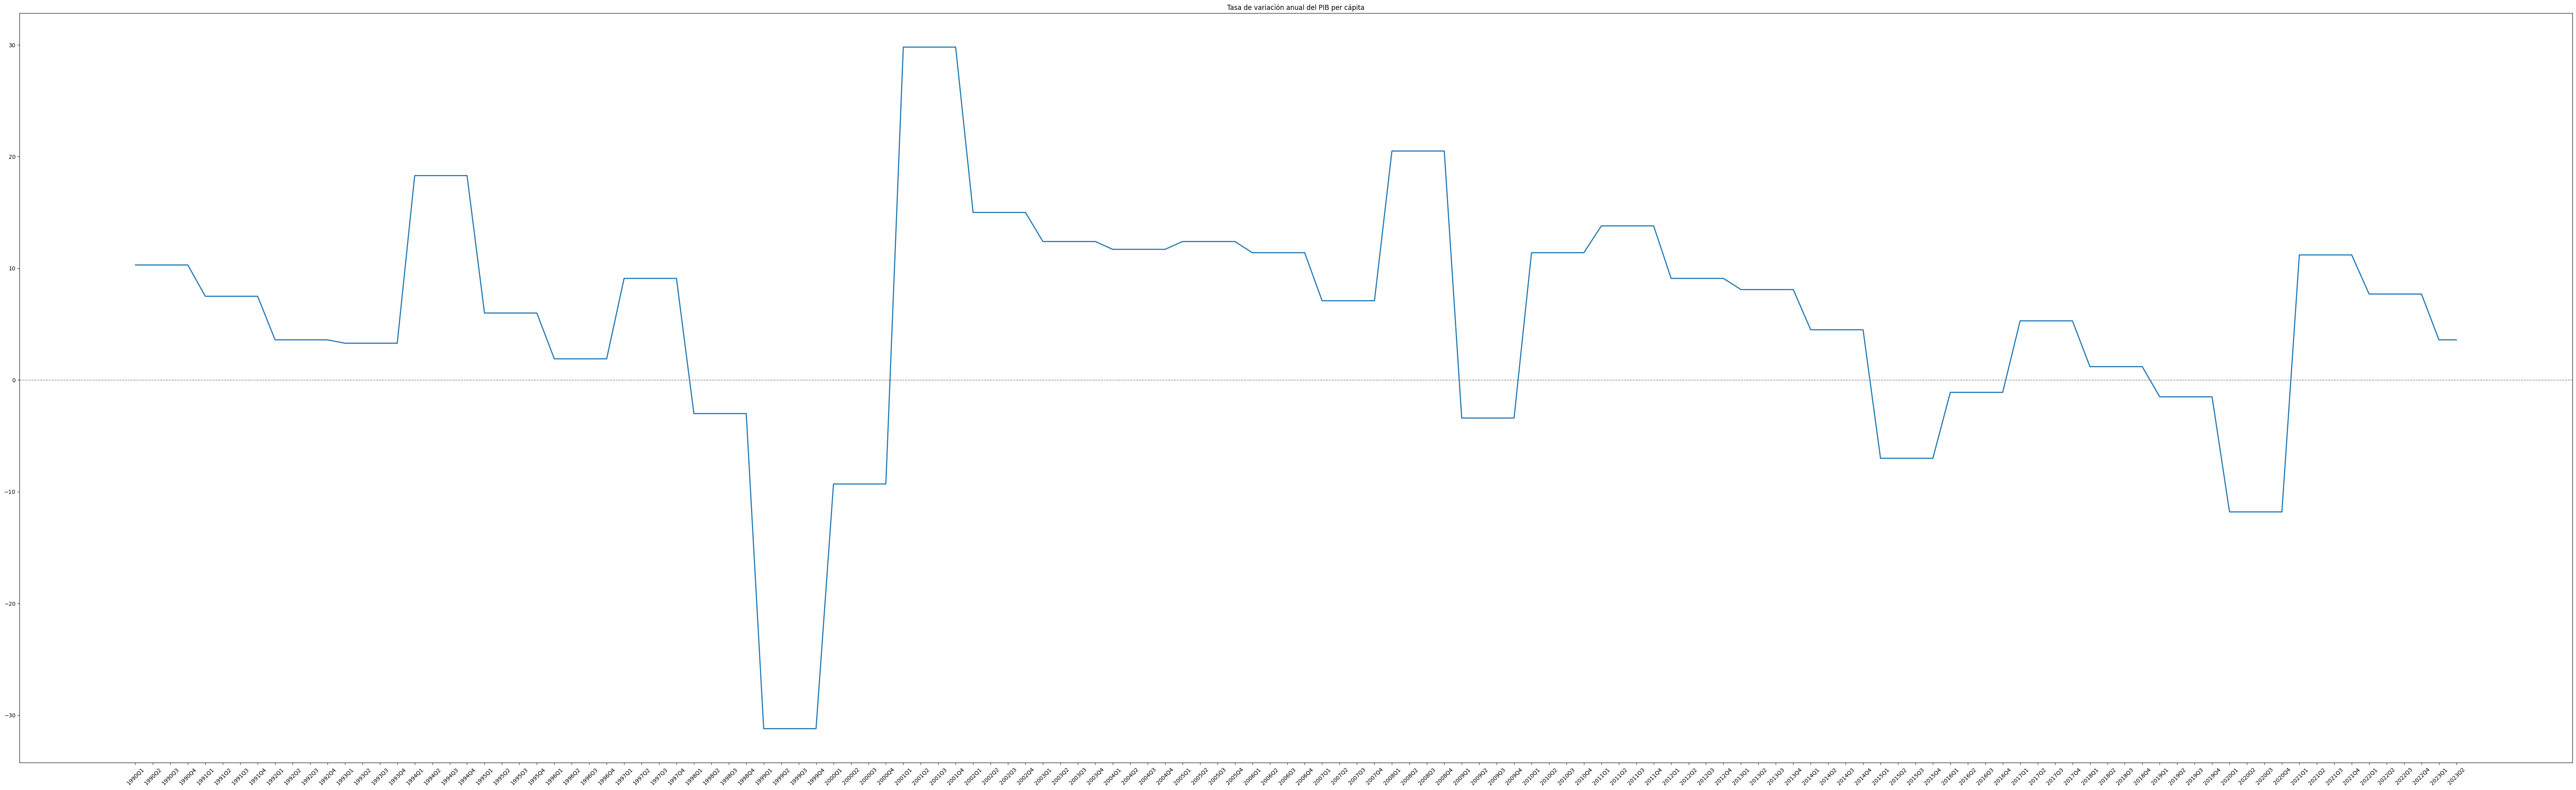

In [ ]:
plt.figure(figsize=(65,20))
plt.plot(pea["periodo"].astype(str),
         pea["Tasa de variación anual del PIB Per cápita"],
         linewidth=2)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xticks(rotation=45)
plt.title("Tasa de variación anual del PIB per cápita")
plt.tight_layout()
plt.show()

El gráfico de la tasa de variación anual del PIB per cápita muestra un comportamiento altamente volátil a lo largo del tiempo, con períodos prolongados de crecimiento positivo interrumpidos por caídas abruptas y episodios de recuperación rápida. Se observa un shock negativo muy marcado, seguido por un rebote fuerte, lo que sugiere una crisis económica profunda y una posterior fase de ajuste o recuperación, posiblemente asociada a cambios estructurales o a políticas económicas expansivas. En los años siguientes, el crecimiento se mantiene mayoritariamente positivo pero con oscilaciones recurrentes, reflejando una economía vulnerable a choques internos y externos. Hacia los períodos más recientes, la serie evidencia nuevas desaceleraciones y repuntes, lo que confirma que, aunque el PIB per cápita tiende a crecer en el largo plazo, su evolución anual es inestable y sensible al contexto macroeconómico, reforzando la necesidad de políticas orientadas a la estabilidad y sostenibilidad del crecimiento.

1.6.1.4 Correlaciones bivariadas

La creación de correlaciones bivariadas es un paso esencial para entender las relaciones entre distintas variables económicas. Se realiza para identificar cómo el movimiento de una variable (por ejemplo, el consumo de los hogares) se asocia con el de otra (como la tasa de variación del PIB per cápita), cuantificando la fuerza y dirección de esta relación. Este análisis no solo nos ayuda a señalar qué componentes del gasto, la inversión o el comercio exterior tienen una relación más estrecha con el PIB, sino que también es fundamental para formular hipótesis sobre interdependencias económicas y prevenir problemas de multicolinealidad en la preparación de modelos predictivos, guiando así la selección de variables para un análisis más profundo y la toma de decisiones de política económica.

In [ ]:
corr_cols = [
    "Tasa de variación anual del PIB Per cápita",
    "Consumo final hogares",
    "Consumo final APU",
    "FBKF",
    "Exportaciones (fob)",
    "Importaciones"
]

pea[corr_cols].corr()

,Tasa de variación anual del PIB Per cápita,Consumo final hogares,Consumo final APU,FBKF,Exportaciones (fob),Importaciones
Tasa de variación anual del PIB Per cápita,1.000000,0.354817,0.066393,0.458777,0.154187,0.220988
Consumo final hogares,0.354817,1.000000,0.270001,0.731108,0.318936,0.712519
Consumo final APU,0.066393,0.270001,1.000000,0.201937,0.134083,0.169478
FBKF,0.458777,0.731108,0.201937,1.000000,0.183244,0.785720
Exportaciones (fob),0.154187,0.318936,0.134083,0.183244,1.000000,0.267629
Importaciones,0.220988,0.712519,0.169478,0.785720,0.267629,1.000000


Esa matriz es de **correlaciones** (de -1 a 1): mientras más cerca de **1**, más se mueven juntas; cerca de **0**, relación lineal débil. Aquí, la **tasa de variación anual del PIB per cápita** se relaciona más con la **inversión (FBKF)** (**0.46**) y, en menor medida, con el **consumo de hogares** (**0.35**), lo que sugiere que cuando sube la inversión y el consumo privado, tiende a mejorar el crecimiento del ingreso por persona. En cambio, la relación con el **consumo público (APU)** es casi nula (**0.07**), indicando que su variación no explica mucho el crecimiento per cápita de forma lineal. Además, hay relaciones fuertes entre variables reales: **FBKF–importaciones (0.79)**, **consumo hogares–FBKF (0.73)** y **consumo hogares–importaciones (0.71)**, lo que es coherente con una economía donde el consumo y la inversión suelen “arrastrar” compras externas; por su parte, las **exportaciones** tienen correlaciones bajas con el resto y con el crecimiento per cápita (**0.15**), insinuando que su efecto es más débil o depende de otros factores (precios, shocks externos, etc.).


1.6.1.5 Variaciones trimestrales de componentes

Las variaciones trimestrales de los componentes del gasto (consumo de hogares y APU, FBKF, exportaciones, importaciones) son vitales para entender la dinámica económica a corto plazo y la reactividad de sus agentes. Este análisis nos permite observar con mayor granularidad cómo cambian estos elementos de la demanda agregada de un trimestre a otro, revelando patrones de crecimiento o contracción más inmediatos que el análisis anual. Al identificar la magnitud y dirección de estos cambios, podemos detectar rápidamente el impacto de eventos económicos específicos, la efectividad de políticas implementadas en el corto plazo, y anticipar posibles tendencias para el resto del año, lo que es fundamental para una toma de decisiones económica ágil y oportuna.

In [ ]:
for c in [
    "Consumo final hogares",
    "Consumo final APU",
    "FBKF",
    "Exportaciones (fob)",
    "Importaciones"
]:
    pea[f"{c}_qoq"] = pea[c].pct_change() * 100

pea[[c+"_qoq" for c in [
    "Consumo final hogares",
    "Consumo final APU",
    "FBKF",
    "Exportaciones (fob)",
    "Importaciones"
]]].describe().T

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,count,mean,std,min,25%,50%,75%,max
Consumo final hogares_qoq,133.0,inf,NaN,-3300.0,-125.000000,-45.454545,36.363636,inf
Consumo final APU_qoq,133.0,inf,NaN,-6100.0,-172.222222,-84.057971,10.000000,inf
FBKF_qoq,133.0,inf,NaN,-5700.0,-156.250000,-59.259259,8.108108,inf
Exportaciones (fob)_qoq,133.0,NaN,NaN,-inf,-205.882353,-114.705882,-33.333333,inf
Importaciones_qoq,133.0,inf,NaN,-4700.0,-182.113821,-91.397849,-5.000000,inf


1.6.1.6 Tendencia y ciclo

El análisis de la tendencia y el ciclo en las variables económicas es esencial para desglosar y comprender las fuerzas subyacentes que impulsan el crecimiento y las fluctuaciones. La tendencia representa el movimiento a largo plazo de una serie, indicando la dirección fundamental de la economía sin las variaciones a corto plazo, lo cual es vital para evaluar el potencial de crecimiento estructural de un país. Por otro lado, el ciclo se refiere a las fluctuaciones recurrentes (expansiones y contracciones) alrededor de esa tendencia a largo plazo, revelando la salud a corto y mediano plazo de la economía, así como la presencia de picos y valles. Estudiar ambos componentes permite a los analistas distinguir entre cambios temporales y estructurales, fundamental para la formulación de políticas que no solo busquen estabilizar la economía en el ciclo actual, sino también promover un crecimiento sostenible a largo plazo.

In [ ]:
analysis_cols = [
    "PIB",
    "Consumo final hogares",
    "Consumo final APU",
    "FBKF",
    "Exportaciones (fob)",
    "Importaciones",
    "Tasa de variación anual del PIB Per cápita"
]

pea[analysis_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PIB,134.0,0.668657,1.750893,-12.1,0.1,0.80,1.500,6.1
Consumo final hogares,134.0,0.694030,1.863773,-11.0,0.0,0.80,1.600,6.0
Consumo final APU,134.0,0.624627,3.109588,-10.6,-0.5,0.70,2.100,10.9
FBKF,134.0,0.817910,5.041182,-24.9,-1.5,0.85,3.600,15.0
Exportaciones (fob),134.0,0.841791,3.567529,-15.2,-0.8,0.55,2.675,14.3
Importaciones,134.0,1.255970,7.353139,-29.3,-2.2,1.05,4.575,25.6
Tasa de variación anual del PIB Per cápita,134.0,5.555224,10.619521,-31.2,1.2,7.50,11.400,29.8


In [ ]:
for c in analysis_cols:
    pea[f"{c}_clip"] = pea[c].clip(lower=-200, upper=200)

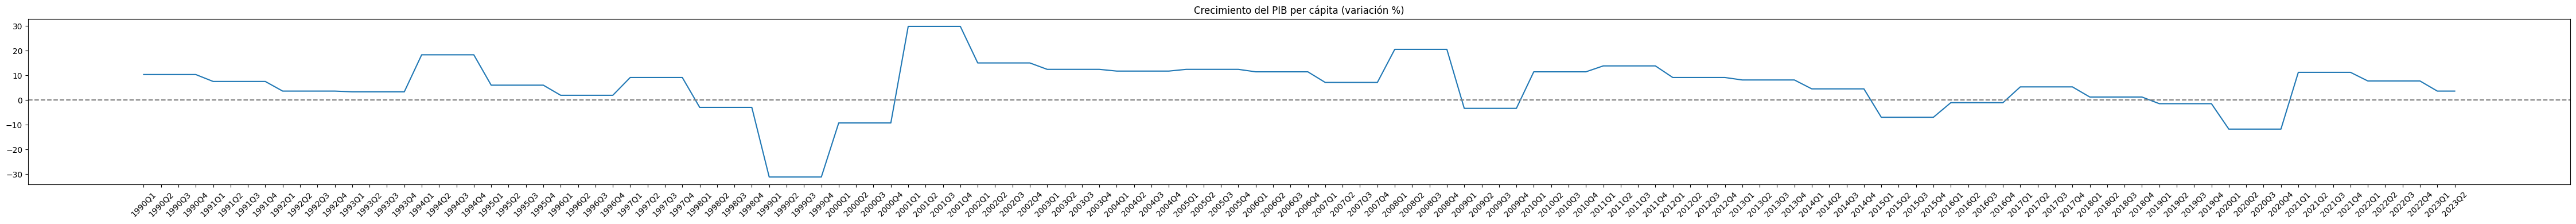

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(45,4))
plt.plot(pea["periodo"].astype(str),
         pea["Tasa de variación anual del PIB Per cápita"])
plt.axhline(0, color="gray", linestyle="--")
plt.xticks(rotation=45)
plt.title("Crecimiento del PIB per cápita (variación %)")
plt.tight_layout()
plt.show()

El gráfico del crecimiento del PIB per cápita evidencia una trayectoria cíclica y volátil, con períodos prolongados de crecimiento positivo interrumpidos por caídas abruptas, destacando un episodio de contracción muy profunda seguido de un rebote excepcionalmente alto, típico de una crisis severa y una recuperación posterior. Tras ese evento, el crecimiento se mantiene mayormente positivo, aunque con oscilaciones recurrentes, lo que refleja una economía sensible a choques internos y externos. En los años más recientes se observan nuevas desaceleraciones y recuperaciones moderadas, sugiriendo que, aunque el ingreso por habitante tiende a crecer en el largo plazo, su evolución anual es inestable, lo que refuerza la necesidad de políticas económicas orientadas a la estabilidad macroeconómica y al fortalecimiento de la inversión y la productividad.

### 1.6.2 Inflación (IPC)

1.6.2.1 Estadísticas descriptivas

In [ ]:
ipc[["Inflacion_Anual"]].describe()

,Inflacion_Anual
count,9.000000
mean,1.023143
std,1.288664
min,-0.341265
25%,0.133168
50%,0.419048
75%,1.724472
max,3.467275


1.6.2.2 Valores faltantes

In [ ]:
ipc[["Inflacion_Anual"]].isna().sum()

,0
Inflacion_Anual,1


1.6.2.3 Evolución temporal

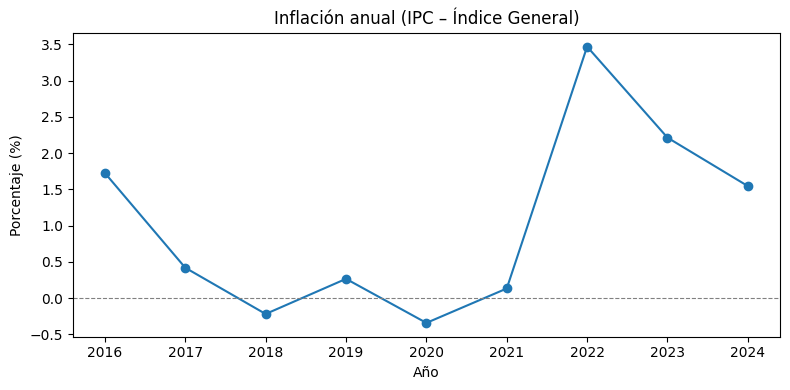

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(ipc["Años"], ipc["Inflacion_Anual"], marker="o")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Inflación anual (IPC – Índice General)")
plt.xlabel("Año")
plt.ylabel("Porcentaje (%)")
plt.tight_layout()
plt.show()

El gráfico de la inflación anual (IPC – índice general) muestra un período inicial de inflación baja e incluso negativa entre 2017 y 2020, lo que sugiere un entorno de debilidad de la demanda y presiones deflacionarias, acentuadas en el año 2020. A partir de 2021 se observa un repunte significativo de la inflación, con un pico marcado en 2022, asociado a choques externos y a la recuperación de la actividad económica. Posteriormente, en 2023 y 2024 la inflación desciende gradualmente, aunque se mantiene en niveles positivos, lo que indica un proceso de normalización de precios, pero aún con presiones inflacionarias moderadas que requieren políticas orientadas a preservar la estabilidad de precios.

1.6.2.4 Identificación de picos

In [ ]:
ipc.sort_values("Inflacion_Anual", ascending=False).head(5)

,Años,INDICE GENERAL,IPC,Inflacion_Anual
7,2022,"108,92",108.92,3.467275
8,2023,"111,33",111.33,2.212633
1,2016,105,105.00,1.724472
9,2024,"113,05",113.05,1.544956
2,2017,"105,44",105.44,0.419048


1.6.2.5 Volatilidad

In [ ]:
ipc["Inflacion_Anual"].std()

1.2886640953691786

La volatilidad de la inflación (1.29) indica que, aunque la inflación promedio se mantiene en niveles relativamente bajos, existen oscilaciones moderadas a lo largo del tiempo, con cambios perceptibles entre años de inflación baja, episodios cercanos a deflación y repuntes inflacionarios puntuales. Esto sugiere que la dinámica de precios no es completamente estable y que está expuesta a choques temporales, principalmente externos o asociados a procesos de recuperación económica, lo que refuerza la necesidad de políticas orientadas a contener fluctuaciones y preservar la estabilidad de precios.

1.6.2.6 Pre-Post 2020

In [ ]:
ipc.assign(periodo=lambda x: np.where(x["Años"] < 2020, "Pre-2020", "Post-2020")) \
   .groupby("periodo")["Inflacion_Anual"] \
   .describe()

,count,mean,std,min,25%,50%,75%,max
periodo,,,,,,,,
Post-2020,5.0,1.403354,1.548533,-0.341265,0.133168,1.544956,2.212633,3.467275
Pre-2020,4.0,0.547880,0.830085,-0.218134,0.145067,0.342591,0.745404,1.724472


Periodo
Post-2020    5
Pre-2020     4
Name: count, dtype: int64


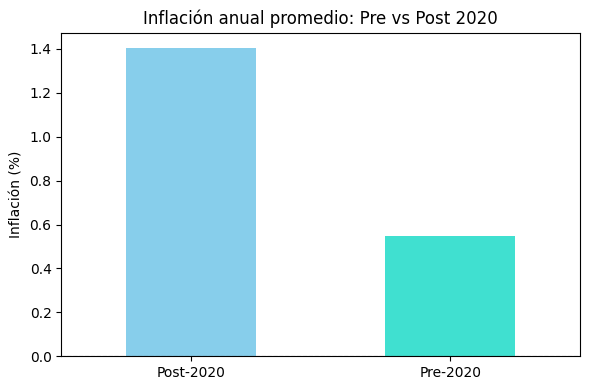

In [ ]:
ipc = ipc.copy()

# 2) Eliminar NaN en inflación
ipc = ipc.dropna(subset=["Inflacion_Anual"])

# 3) Crear variable de periodo
ipc["Periodo"] = np.where(ipc["Años"] < 2020, "Pre-2020", "Post-2020")

# 4) Verificar que existan ambos grupos (diagnóstico)
print(ipc["Periodo"].value_counts())

# 5) Calcular promedio por periodo
ipc_group = ipc.groupby("Periodo")["Inflacion_Anual"].mean()

# 6) Gráfico
plt.figure(figsize=(6,4))
mis_colores = ["skyblue", "turquoise"]

# Y luego graficas:
ipc_group.plot(kind="bar", color=mis_colores)

plt.title("Inflación anual promedio: Pre vs Post 2020")
plt.ylabel("Inflación (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

El gráfico comparativo muestra un cambio claro en el régimen inflacionario al contrastar los períodos pre y post 2020. Antes de 2020, la inflación promedio se mantenía en niveles muy bajos, reflejando un contexto de débil presión sobre los precios e incluso episodios cercanos a la deflación. En el período posterior a 2020, la inflación promedio aumenta de forma notable, lo que sugiere la presencia de choques asociados a la recuperación económica y al entorno internacional, que elevaron los precios de manera más persistente. Este contraste evidencia que, tras 2020, la inflación pasó de un escenario de estabilidad a uno de mayor presión inflacionaria, lo que implica nuevos retos para la política económica orientada a la estabilidad de precios.

### 1.6.3 Déficit fiscal

1.6.3.1 Estadísticas descriptivas

In [ ]:
deficit[["Deficit_PIB"]].describe()

,Deficit_PIB
count,25.000000
mean,-2.279600
std,3.681386
min,-10.290000
25%,-3.710000
50%,-1.390000
75%,0.570000
max,2.920000


1.6.3.2 Valores faltantes

In [ ]:
deficit[["Deficit_PIB"]].isna().sum()

,0
Deficit_PIB,0


1.6.3.3 Evolución temporal

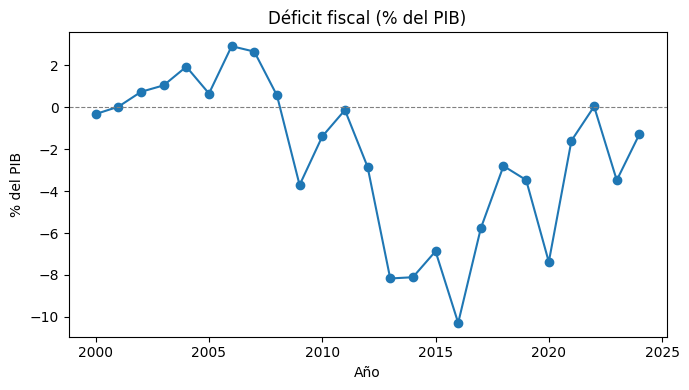

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(deficit["Año"], deficit["Deficit_PIB"], marker="o")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.title("Déficit fiscal (% del PIB)")
plt.xlabel("Año")
plt.ylabel("% del PIB")
plt.tight_layout()
plt.show()

El gráfico del déficit fiscal (% del PIB) evidencia una trayectoria marcadamente cíclica, con años de equilibrio o incluso superávit a inicios del período, seguidos por un deterioro fiscal pronunciado en la década siguiente. Se observa una expansión significativa del déficit en los años de crisis, alcanzando un mínimo cercano al -10 % del PIB, lo que refleja una fuerte presión sobre las finanzas públicas asociada a choques económicos y a políticas fiscales expansivas. Posteriormente, el déficit muestra una recuperación gradual, aunque con nuevas oscilaciones, indicando esfuerzos de consolidación fiscal que no logran estabilizarse de manera sostenida. En conjunto, el comportamiento del déficit fiscal sugiere una política fiscal reactiva y vulnerable a shocks, lo que plantea la necesidad de estrategias de mediano plazo orientadas a mejorar la sostenibilidad de las cuentas públicas.

1.6.3.4 Identificación de años críticos

In [ ]:
deficit.sort_values("Deficit_PIB").head(3)   # mayor déficit

,Año,Deficit_PIB
16,2016,-10.29
13,2013,-8.17
14,2014,-8.11


In [ ]:
deficit.sort_values("Deficit_PIB", ascending=False).head(3)  # superávit

,Año,Deficit_PIB
6,2006,2.92
7,2007,2.66
4,2004,1.94


La identificación de años críticos muestra que el mayor deterioro fiscal se concentró en 2016, cuando el déficit alcanzó aproximadamente −10,3 % del PIB, seguido por 2013 y 2014, con déficits superiores al −8 % del PIB, lo que evidencia un período de fuerte desequilibrio de las finanzas públicas asociado a choques económicos y a una mayor presión del gasto. En contraste, los años de mejor desempeño fiscal se registraron en 2006, 2007 y 2004, con superávits cercanos al 3 % del PIB, reflejando una etapa de mayor holgura fiscal y capacidad de ahorro del sector público. En conjunto, estos resultados confirman la existencia de fases claramente diferenciadas en la política fiscal, alternando períodos de expansión del gasto y deterioro del balance con otros de consolidación y superávit.

1.6.3.5 Volatilidad

La volatilidad del déficit fiscal es un indicador crucial que se analiza para entender la estabilidad de las finanzas públicas de un país. Evaluar su volatilidad nos permite medir qué tan impredecible o errático es el comportamiento del déficit a lo largo del tiempo, lo cual es fundamental para la gestión económica. Una alta volatilidad puede señalar una mayor incertidumbre en la recaudación de ingresos o en la ejecución del gasto público, complicando la planificación presupuestaria y afectando la confianza de los inversores. Por ello, este análisis es vital para identificar periodos de inestabilidad fiscal, comprender los riesgos asociados a cambios abruptos y diseñar políticas que promuevan una mayor predictibilidad y sostenibilidad en las cuentas del gobierno.

In [ ]:
deficit["Deficit_PIB"].std()

3.681386151981343

La volatilidad del déficit fiscal (3.68) indica fluctuaciones elevadas en el balance fiscal a lo largo del tiempo, reflejando cambios bruscos entre años de superávit y períodos de déficit profundo. Este nivel de volatilidad sugiere una política fiscal poco estable, altamente sensible a los ciclos económicos y a choques externos, lo que dificulta la planificación de mediano y largo plazo y refuerza la necesidad de reglas fiscales y mecanismos de estabilización que permitan suavizar estas variaciones y mejorar la sostenibilidad de las finanzas públicas.

1.6.3.6 Pre-Post 2020

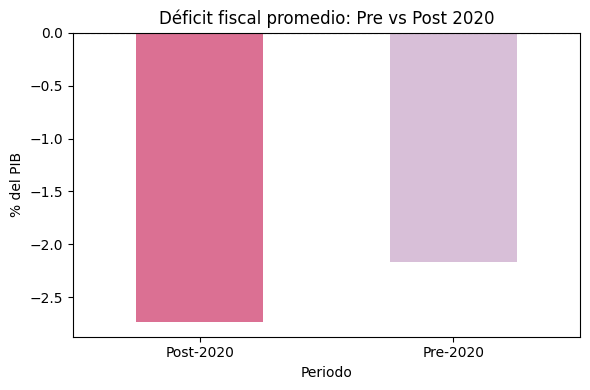

In [ ]:
deficit_plot = deficit.dropna(subset=["Deficit_PIB"]).copy()
deficit_plot["Periodo"] = np.where(deficit_plot["Año"] < 2020, "Pre-2020", "Post-2020")

deficit_group = deficit_plot.groupby("Periodo")["Deficit_PIB"].mean()

plt.figure(figsize=(6,4))
mis_colores = ["palevioletred", "thistle"]
deficit_group.plot(kind="bar", color=mis_colores)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.title("Déficit fiscal promedio: Pre vs Post 2020")
plt.ylabel("% del PIB")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El gráfico evidencia que el déficit fiscal promedio se profundiza en el período posterior a 2020, pasando de un nivel cercano a −2 % del PIB en el período pre-2020 a valores alrededor de −2,7 % del PIB en el período post-2020. Esto refleja un deterioro del balance fiscal asociado a mayores necesidades de gasto y a menores ingresos en el contexto de crisis y recuperación económica. En términos de política económica, el resultado sugiere que, tras 2020, la política fiscal se volvió más expansiva y menos sostenible, incrementando la presión sobre las finanzas públicas y resaltando la importancia de estrategias de consolidación fiscal en el mediano plazo.

### 1.6.4 Deuda pública

1.6.4.1 Estadísticas descriptivas

In [ ]:
deuda[["Deuda_PIB"]].describe()

,Deuda_PIB
count,75.000000
mean,32.684000
std,26.590275
min,2.200000
25%,6.550000
50%,26.500000
75%,54.100000
max,87.100000


1.6.4.2 Valores faltantes

In [ ]:
deuda[["Deuda_PIB"]].isna().sum()

,0
Deuda_PIB,0


1.6.4.3 Evolución temporal

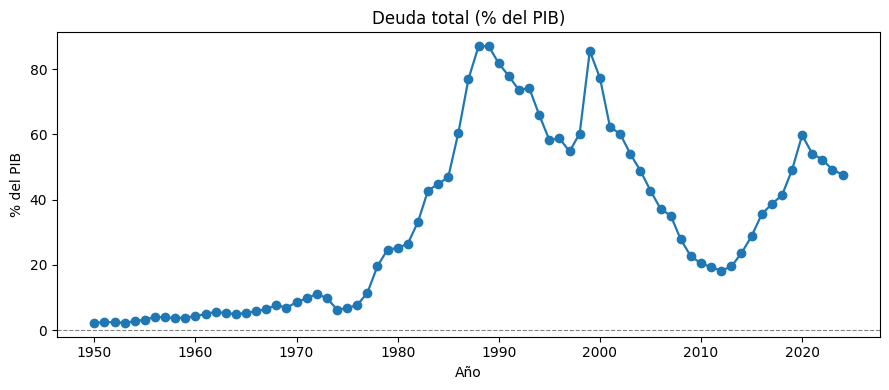

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(deuda["Año"], deuda["Deuda_PIB"], marker="o", linewidth=1.6)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.title("Deuda total (% del PIB)")
plt.xlabel("Año")
plt.ylabel("% del PIB")
plt.tight_layout()
plt.show()

El gráfico de la deuda total como porcentaje del PIB muestra una tendencia creciente de largo plazo, con episodios de acumulación acelerada seguidos por fases de ajuste. Durante las décadas iniciales, la deuda se mantiene en niveles bajos y estables, pero a partir de los años ochenta se observa un incremento pronunciado, alcanzando picos elevados que reflejan períodos de financiamiento intensivo del déficit fiscal y choques macroeconómicos. Posteriormente, se evidencian esfuerzos de reducción de la deuda, aunque no sostenidos, ya que nuevos episodios de expansión vuelven a elevarla en años recientes. En conjunto, la dinámica sugiere que la deuda pública ha sido utilizada de forma procíclica, aumentando en crisis y reduciéndose parcialmente en recuperaciones, lo que plantea desafíos para la sostenibilidad fiscal y la estabilidad macroeconómica en el largo plazo.

1.6.4.4 Identificación de valores críticos

In [ ]:
deuda.sort_values("Deuda_PIB", ascending=False).head(5)

,Año,Deuda_PIB
38,1988,87.1
39,1989,87.1
49,1999,85.6
40,1990,81.8
41,1991,77.9


In [ ]:
deuda.sort_values("Deuda_PIB").head(5)

,Año,Deuda_PIB
0,1950,2.2
3,1953,2.2
1,1951,2.4
2,1952,2.4
4,1954,2.7


La identificación de años críticos en la deuda total como porcentaje del PIB muestra que los niveles más elevados se registraron a finales de los años ochenta y finales de los noventa, destacando 1988 y 1989, con valores cercanos al 87 % del PIB, y 1999, con alrededor del 86 %, lo que evidencia períodos de alto endeudamiento y fuerte vulnerabilidad fiscal. En contraste, los niveles más bajos de deuda corresponden a los primeros años de la serie, entre 1950 y 1954, con valores cercanos al 2–3 % del PIB, reflejando una etapa de baja dependencia del financiamiento vía deuda. Este contraste confirma un cambio estructural en la dinámica fiscal, pasando de un escenario de bajo endeudamiento a uno de mayor exposición y riesgo fiscal en décadas posteriores.

1.6.4.5 Volatilidad

In [ ]:
deuda["Deuda_PIB"].std()

26.590274791989522

La volatilidad de la deuda total (% del PIB), medida por una desviación estándar de 26,59, indica fluctuaciones muy elevadas en el nivel de endeudamiento a lo largo del tiempo. Este valor refleja la presencia de cambios estructurales y episodios de acumulación acelerada de deuda, seguidos por fases de ajuste parcial, más que variaciones suaves alrededor de una tendencia estable. En términos de política económica, una volatilidad tan alta sugiere una gestión de la deuda fuertemente influenciada por crisis y shocks macroeconómicos, lo que incrementa la vulnerabilidad fiscal y resalta la necesidad de estrategias de endeudamiento de largo plazo orientadas a la sostenibilidad y estabilidad fiscal.

1.6.4.6 Pre-Post 2020

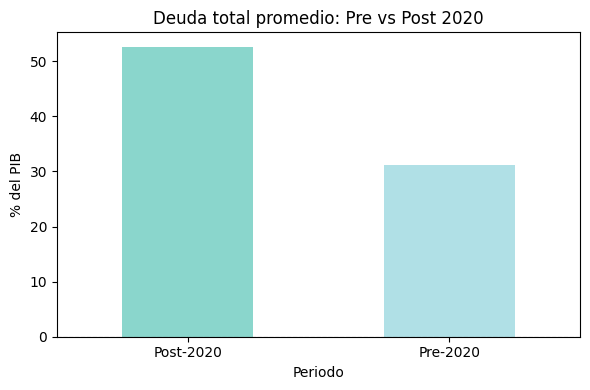

In [ ]:
deuda_plot = deuda.dropna(subset=["Deuda_PIB"]).copy()
deuda_plot["Periodo"] = np.where(deuda_plot["Año"] < 2020, "Pre-2020", "Post-2020")

deuda_group = deuda_plot.groupby("Periodo")["Deuda_PIB"].mean()

plt.figure(figsize=(6,4))
mis_colores=["#8AD6CC", "powderblue"]
deuda_group.plot(kind="bar", color=mis_colores)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.title("Deuda total promedio: Pre vs Post 2020")
plt.ylabel("% del PIB")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El gráfico evidencia un aumento significativo del nivel promedio de deuda pública en el período posterior a 2020, pasando de valores cercanos al 31 % del PIB en el período pre-2020 a alrededor del 52 % del PIB en el período post-2020. Este incremento refleja una mayor dependencia del endeudamiento como mecanismo de financiamiento frente a choques económicos recientes y a la necesidad de sostener el gasto público en un contexto de crisis y recuperación. En términos de política económica, el resultado sugiere un deterioro en la sostenibilidad fiscal en el período posterior a 2020, lo que refuerza la importancia de implementar estrategias de consolidación fiscal y gestión prudente de la deuda para evitar riesgos macroeconómicos en el mediano y largo plazo.

### 1.6.5 Precio del petróleo

1.6.5.1 Estadísticas descriptivas

In [ ]:
pet[["Crudo_Oriente"]].describe()

,Crudo_Oriente
count,60.000000
mean,66.353333
std,19.065893
min,16.700000
25%,59.375000
50%,68.550000
75%,77.100000
max,107.400000


1.6.5.2 Evolución temporal

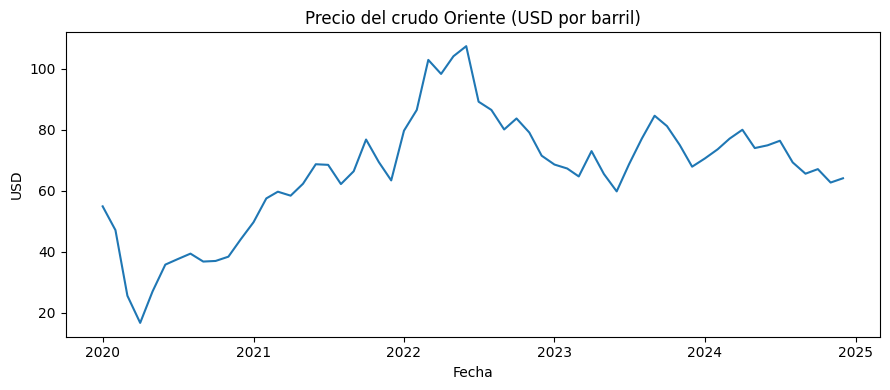

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(pet["Fecha"], pet["Crudo_Oriente"], linewidth=1.5)
plt.title("Precio del crudo Oriente (USD por barril)")
plt.xlabel("Fecha")
plt.ylabel("USD")
plt.tight_layout()
plt.show()

El gráfico del precio del crudo Oriente (USD por barril) muestra una alta volatilidad en el período analizado, con una fuerte caída inicial en 2020, seguida por una rápida recuperación y un pico marcado en 2022, cuando los precios superan los 100 USD por barril. Posteriormente, se observa una corrección y estabilización relativa, con precios fluctuando en un rango medio-alto durante 2023 y 2024, aunque manteniendo oscilaciones frecuentes. Esta dinámica refleja la influencia de choques externos, como la pandemia, tensiones geopolíticas y cambios en la demanda global, y subraya la importancia del precio del petróleo como un factor clave de transmisión hacia las finanzas públicas, la balanza externa y la inflación en economías dependientes del crudo.

1.6.5.3 Identificación de meses críticos

La identificación de meses críticos, especialmente en variables como el precio del petróleo, es fundamental para analizar periodos de eventos económicos extremos. Nos permite pinpointar los momentos históricos en los que los precios alcanzaron sus mínimos o máximos más significativos. Este análisis es crucial para entender las causas subyacentes de estas fluctuaciones, como crisis de oferta, cambios geopolíticos, o variaciones en la demanda global. Al identificar estos meses, podemos estudiar su impacto en otras variables macroeconómicas y evaluar la resiliencia de la economía ante shocks externos, informando así la preparación para futuras volatilidades y la formulación de políticas que mitiguen sus efectos.

In [ ]:
pet.sort_values("Crudo_Oriente").head(5)      # mínimos

,Año,Mes,Crudo Oriente,Crudo_Oriente,Fecha
3,2020,4,"16,7",16.7,2020-04-01
2,2020,3,"25,6",25.6,2020-03-01
4,2020,5,27,27.0,2020-05-01
5,2020,6,"35,8",35.8,2020-06-01
8,2020,9,"36,8",36.8,2020-09-01


In [ ]:
pet.sort_values("Crudo_Oriente", ascending=False).head(5)  # máximos

,Año,Mes,Crudo Oriente,Crudo_Oriente,Fecha
29,2022,6,"107,4",107.4,2022-06-01
28,2022,5,"104,1",104.1,2022-05-01
26,2022,3,"102,9",102.9,2022-03-01
27,2022,4,"98,3",98.3,2022-04-01
30,2022,7,"89,2",89.2,2022-07-01


La identificación de valores extremos del precio del crudo Oriente muestra que los mínimos históricos se concentran en 2020, con un piso cercano a 16,7 USD por barril en abril de 2020, reflejando el colapso de la demanda internacional durante la pandemia. En contraste, los máximos se registran en 2022, alcanzando un pico de aproximadamente 107 USD por barril, asociado a la recuperación económica global y a tensiones geopolíticas que restringieron la oferta. Este contraste evidencia una volatilidad extrema del precio del petróleo, con implicaciones directas sobre los ingresos fiscales, la balanza externa y la estabilidad macroeconómica, especialmente en economías dependientes del sector petrolero.

1.6.5.4 Volatilidad

In [ ]:
pet["Crudo_Oriente"].std()

19.06589346936856

La volatilidad del precio del crudo Oriente (19,07 USD) evidencia fluctuaciones muy elevadas en el mercado petrolero durante el período analizado, reflejando cambios bruscos entre fases de colapso y picos pronunciados de precios. Este nivel de volatilidad está asociado a choques externos significativos, como la pandemia, la recuperación económica global y tensiones geopolíticas, lo que convierte al precio del petróleo en una fuente importante de incertidumbre macroeconómica. En términos de política económica, una volatilidad tan alta implica riesgos relevantes para los ingresos fiscales y la planificación presupuestaria, especialmente en economías con alta dependencia del crudo.

1.6.5.5 Agregación anual

La agregación anual es un proceso crucial en el análisis económico que consiste en consolidar datos de menor periodicidad (como trimestrales o mensuales) en valores anuales. Esta práctica es fundamental porque simplifica la información, reduciendo el ruido de las fluctuaciones de corto plazo y permitiendo una visión más clara de las tendencias a largo término y los cambios estructurales en la economía. Además, facilita la comparación de variables económicas entre diferentes años o con datos históricos, lo cual es esencial para evaluar el desempeño económico global, establecer metas de política a mediano plazo y comunicar de manera efectiva los resultados macroeconómicos.

In [ ]:
pet_anual = (
    pet.assign(Año=lambda x: x["Fecha"].dt.year)
       .groupby("Año")["Crudo_Oriente"]
       .mean()
       .reset_index()
)

### 1.6.6 Correlaciones bivariadas

In [ ]:
# PEA debe tener: Año, Tasa de variación anual del PIB Per cápita

pib_anual = (
    pea.groupby("Año")["Tasa de variación anual del PIB Per cápita"]
       .mean()
       .reset_index()
       .rename(columns={"Tasa de variación anual del PIB Per cápita": "PIB_pc"})
)

In [ ]:
corr_df = pib_anual.merge(
    ipc.rename(columns={"Años": "Año"})[["Año", "Inflacion_Anual"]], on="Año", how="inner"
).merge(
    deficit[["Año", "Deficit_PIB"]], on="Año", how="inner"
).merge(
    deuda[["Año", "Deuda_PIB"]], on="Año", how="inner"
).merge(
    pet_anual.rename(columns={"Crudo_Oriente": "Petroleo"}), on="Año", how="inner"
)

corr_df.head()

,Año,PIB_pc,Inflacion_Anual,Deficit_PIB,Deuda_PIB,Petroleo,Periodo
0,2020,-11.8,-0.341265,-7.38,59.8,36.700000,Post-2020
1,2021,11.2,0.133168,-1.59,54.1,63.583333,Post-2020
2,2022,7.7,3.467275,0.04,52.3,89.083333,Post-2020
3,2023,3.6,2.212633,-3.48,49.2,71.116667,Post-2020


In [ ]:
corr_vars = ["PIB_pc", "Inflacion_Anual", "Deficit_PIB", "Deuda_PIB", "Petroleo"]

corr_matrix = corr_df[corr_vars].corr()
corr_matrix

,PIB_pc,Inflacion_Anual,Deficit_PIB,Deuda_PIB,Petroleo
PIB_pc,1.000000,0.470358,0.929159,-0.709482,0.792239
Inflacion_Anual,0.470358,1.000000,0.685069,-0.740274,0.908042
Deficit_PIB,0.929159,0.685069,1.000000,-0.660650,0.922316
Deuda_PIB,-0.709482,-0.740274,-0.660650,1.000000,-0.806784
Petroleo,0.792239,0.908042,0.922316,-0.806784,1.000000


La creación de correlaciones bivariadas es un paso fundamental para entender las interrelaciones entre distintas variables macroeconómicas. Se realiza para identificar cómo el movimiento de una variable (por ejemplo, la inflación o el precio del petróleo) se asocia con el de otra (como la tasa de variación del PIB per cápita), cuantificando la fuerza y dirección de esta relación. Este análisis es crucial para señalar qué variables macroeconómicas tienen una conexión más estrecha con el crecimiento del PIB, permitiendo formular hipótesis sobre interdependencias económicas, prever posibles impactos de políticas y detectar riesgos de multicolinealidad en modelos predictivos, lo que orienta la selección de variables para un análisis más profundo y la toma de decisiones económicas informadas.

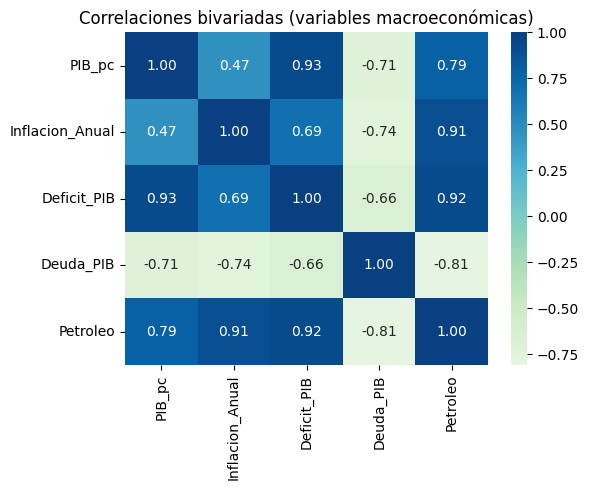

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="GnBu",
    center=0
)

plt.title("Correlaciones bivariadas (variables macroeconómicas)")
plt.tight_layout()
plt.show()

La matriz de correlaciones bivariadas evidencia relaciones macroeconómicas claras y coherentes. El precio del petróleo presenta una correlación fuerte y positiva con el PIB per cápita (0.79), la inflación (0.91) y el déficit fiscal (0.92), lo que indica que los ciclos petroleros influyen directamente tanto en el crecimiento como en las presiones inflacionarias y en el comportamiento fiscal. A su vez, el PIB per cápita se relaciona fuertemente con el déficit fiscal (0.93), sugiriendo que en períodos de mayor crecimiento también se observan cambios significativos en el balance fiscal. En contraste, la deuda pública mantiene correlaciones negativas con el PIB per cápita (−0.71), la inflación (−0.74), el déficit (−0.66) y el petróleo (−0.81), lo que refleja que los episodios de mayor endeudamiento tienden a coincidir con contextos de bajo crecimiento, menor dinamismo económico y choques adversos. En conjunto, los resultados muestran una economía altamente dependiente del ciclo petrolero, con interacciones fuertes entre crecimiento, inflación y política fiscal, y una dinámica de deuda que se intensifica en períodos de estrés macroeconómico.

In [ ]:
df = pd.read_csv('PEE.csv', encoding='latin-1', sep=';')

In [ ]:
df

,Período,Mes,Día,Reservas internacionales,Pasivos Monetarios,Emisión monetaria,Dinero Electrónico,Reservas bancarias,Depósitos a la vista,Cuasidinero total,...,Gasto de Consumo Final de los Hogares,Formación Bruta de Capital,Formación bruta de capital fijo,Variación de las existencias,Exportaciones,Importaciones,Producto Interno Bruto,Población,PIB Per cápita \n(USD),Tasa de variación anual del PIB Per cápita\n(en porcentaje)
0,2006,1,31,"1.939,90","409,6",62,0,"347,6","3143,7","5141,9",...,"29.901,50","8.278,30","7.574,30",704,"16.312,40","13.771,50","45.690,80",13.852.369,"3.298,40","11,4"
1,2006,2,28,"1.913,50","493,1","60,4",0,"432,7","3124,3",5273,...,"29.901,50","8.278,30","7.574,30",704,"16.312,40","13.771,50","45.690,80",13.852.369,"3.298,40","11,4"
2,2006,3,31,"2.350,70","485,1","61,9",0,"423,2","3264,7","5353,8",...,"29.901,50","8.278,30","7.574,30",704,"16.312,40","13.771,50","45.690,80",13.852.369,"3.298,40","11,4"
3,2006,4,30,"2.701,30","514,6","61,2",0,"453,5","3318,2","5407,5",...,"29.901,50","8.278,30","7.574,30",704,"16.312,40","13.771,50","45.690,80",13.852.369,"3.298,40","11,4"
4,2006,5,31,"2.229,70","432,8","62,5",0,"370,3","3460,5","5535,2",...,"29.901,50","8.278,30","7.574,30",704,"16.312,40","13.771,50","45.690,80",13.852.369,"3.298,40","11,4"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,2023,8,31,"6.358,60","5.562,70","86,8",0,"5.475,90","14.670,00","47.853,20",...,"79.510,90","25.017,60","24.049,90","967,7","34.606,80","34.444,30","121.147,10",17.834.831,"6.792,70","3,6"
212,2023,9,30,"6.312,20","5.688,90","87,3",0,"5.601,60","14.182,00","48.118,20",...,"79.510,90","25.017,60","24.049,90","967,7","34.606,80","34.444,30","121.147,10",17.834.831,"6.792,70","3,6"
213,2023,10,31,"6.007,60","5.627,60","87,7",0,"5.539,90","13.959,70","48.302,70",...,"79.510,90","25.017,60","24.049,90","967,7","34.606,80","34.444,30","121.147,10",17.834.831,"6.792,70","3,6"
214,2023,11,30,"5.658,10","5.266,00","86,7",0,"5.179,30","14.035,10","48.419,30",...,"79.510,90","25.017,60","24.049,90","967,7","34.606,80","34.444,30","121.147,10",17.834.831,"6.792,70","3,6"


# 2. Preprocesamiento

Este proceso implica tareas como la limpieza de datos (manejo de valores faltantes y atípicos), la estandarización o normalización de variables para asegurar que tengan escalas comparables, y la preparación para la selección de características. La importancia del preprocesamiento radica en que los modelos de aprendizaje automático son muy sensibles a la calidad y el formato de los datos de entrada; un buen preprocesamiento puede mejorar drásticamente el rendimiento del modelo, la precisión de las predicciones y la robustez del análisis, mientras que datos mal preprocesados pueden llevar a resultados sesgados, ineficientes o incluso incorrectos.

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1) Normalizar nombres de columnas
# =========================
df.columns = (
    df.columns.astype(str)
    .str.replace("\n", " ", regex=False)
    .str.replace("\r", " ", regex=False)
    .str.replace("\t", " ", regex=False)
    .str.replace("  ", " ", regex=False)
    .str.strip()
)

# =========================
# 2) Identificar correctamente el TARGET
# =========================
target_key = "Tasa de variación anual del PIB Per cápita"
candidatos = [c for c in df.columns if target_key in c]
if len(candidatos) == 0:
    raise ValueError("No se encontró la columna target.")
TARGET = candidatos[0]

# =========================
# 3) Limpieza numérica del TARGET (sin distorsión)
# =========================
if df[TARGET].dtype == "object":
    s = df[TARGET].astype(str).str.strip()
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(".", "", regex=False)
    s = s.str.replace(",", ".", regex=False)
    df[TARGET] = pd.to_numeric(s, errors="coerce")

# =========================
# 4) Limpieza numérica del resto de variables (excluye target)
# =========================
for col in df.columns[3:]:
    if col == TARGET:
        continue
    if df[col].dtype == "object":
        s = df[col].astype(str).str.strip()
        s = s.str.replace(" ", "", regex=False)
        s = s.str.replace(".", "", regex=False)
        s = s.str.replace(",", ".", regex=False)
        df[col] = pd.to_numeric(s, errors="coerce")

# =========================
# 5) Construcción de fecha y orden temporal
# =========================
df["fecha"] = pd.to_datetime(
    dict(year=df["Período"], month=df["Mes"], day=1),
    errors="coerce"
)
df = df.sort_values("fecha").reset_index(drop=True)

# =========================
# 6) Eliminación de columnas problemáticas
# =========================
col_sparse = "Activa de Corto Plazo para el segmento Productivo Corporativo"
if col_sparse in df.columns:
    df = df.drop(columns=[col_sparse])

# =========================
# 7) Control de multicolinealidad en inflación
# =========================
for c in ["Inflación Mensual", "Inflación Acumulada"]:
    if c in df.columns:
        df = df.drop(columns=[c])

print("Preprocesamiento finalizado. Target:", TARGET)


Preprocesamiento finalizado. Target: Tasa de variación anual del PIB Per cápita (en porcentaje)


# 3. Transformación

En la etapa de transformación de datos se construyó una estructura temporal coherente mediante la generación de una variable de fecha y la ordenación cronológica de las observaciones, eliminando componentes redundantes como el día y variables con alta proporción de valores faltantes para evitar sesgos en el modelado. Posteriormente, las variables macroeconómicas expresadas en niveles —monetarias, reales y fiscales— fueron transformadas mediante variaciones logarítmicas y tasas de crecimiento, con el fin de reducir la no estacionariedad, capturar la dinámica económica y mejorar la capacidad explicativa de los modelos. Para controlar problemas de multicolinealidad, se seleccionó únicamente la inflación anual como indicador de precios y se descartaron medidas redundantes. Asimismo, se incorporaron retardos temporales (lags) de las variables explicativas para modelar relaciones dinámicas y garantizar una predicción genuinamente temporal de la tasa de variación anual del PIB per cápita, definida como variable objetivo. Estas transformaciones permiten representar de forma consistente los efectos rezagados de la política monetaria, fiscal y del sector real sobre el crecimiento económico, evitando fuga de información y fortaleciendo la robustez y validez econométrica del proceso predictivo.

In [ ]:
import numpy as np
import pandas as pd

# =========================
# 1) Transformaciones económicas (variaciones logarítmicas)
# =========================
cols_nivel = [
    "Reservas internacionales","Pasivos Monetarios","Emisión monetaria",
    "Dinero Electrónico","Reservas bancarias","Depósitos a la vista",
    "Cuasidinero total","Cuasidinero ahorro","Cuasidinero plazo",
    "Crédito restringido","Operaciones de Reporto","Otros depósitos",
    "Crédito total","Cartera","Básica","Pasiva","Activa",
    "Gasto de consumo final del Gobierno General",
    "Gasto de Consumo Final de los Hogares",
    "Formación Bruta de Capital",
    "Formación bruta de capital fijo",
    "Exportaciones","Importaciones",
    "Producto Interno Bruto"
]

for c in cols_nivel:
    if c in df.columns:
        x = df[c].astype(float)
        df[f"var_{c}"] = np.where(x > 0, np.log(x), np.nan)
        df[f"var_{c}"] = pd.Series(df[f"var_{c}"]).diff()

# Variables con posibles valores negativos
if "Variación de las existencias" in df.columns:
    df["diff_Variación_existencias"] = df["Variación de las existencias"].astype(float).diff()

# =========================
# 2) Construcción de retardos (lags)
# =========================
lags = [1, 3, 6, 12]

features_base = [c for c in df.columns if c.startswith("var_") or c.startswith("diff_")]
if "Inflación Anual" in df.columns:
    features_base.append("Inflación Anual")

for c in features_base:
    for l in lags:
        df[f"{c}_lag{l}"] = df[c].shift(l)

# =========================
# 3) Dataset final (sin fuga de información)
# =========================
DROP_TIME_COLS = ["Período", "Mes", "Día"]
drop_leak_cols = ["PIB Per cápita (USD)", "fecha"] + [c for c in DROP_TIME_COLS if c in df.columns]

X = df.drop(columns=[TARGET] + drop_leak_cols, errors="ignore")
y = df[TARGET].astype(float)

data = pd.concat([X, y.rename("y")], axis=1).dropna().reset_index(drop=True)

X_final = data.drop(columns=["y"])
y_final = data["y"]

print("Transformación completada.")
print("X_final:", X_final.shape)
print("y_final:", y_final.shape)


Transformación completada.
X_final: (0, 157)
y_final: (0,)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_1127/740326049.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{c}_lag{l}"] = df[c].shift(l)
/tmp/ipykernel_1127/740326049.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

In [ ]:
# Ver primeras filas de variaciones log
var_cols = [c for c in df.columns if c.startswith('var_')][:5]
print('Variaciones logarítmicas (primeras 5 columnas):')
print(df[var_cols].dropna().head(5).round(4))
print()

# Ver primeras filas de lags
lag_cols = [c for c in df.columns if '_lag1' in c][:5]
print('Rezagos lag1 (primeras 5 columnas):')
print(df[lag_cols].dropna().head(5).round(4))
print()

print('Shape final:', X_final.shape)
print('Total columnas:', X_final.shape[1])

Variaciones logarítmicas (primeras 5 columnas):
     var_Reservas internacionales  var_Pasivos Monetarios  \
107                       -0.3952                 -0.0017   
108                       -0.0775                 -0.2283   
109                        0.0170                 -0.0543   
110                       -0.0134                  0.1029   
111                       -0.0641                 -0.2218   

     var_Emisión monetaria  var_Dinero Electrónico  var_Reservas bancarias  
107                -0.0172                  0.0000                 -0.0013  
108                 0.0092                  0.0000                 -0.2350  
109                -0.0034                  1.0986                 -0.0559  
110                -0.0115                  0.2877                  0.1063  
111                 0.0012                  0.2231                 -0.2292  

Rezagos lag1 (primeras 5 columnas):
    var_Reservas internacionales_lag1  var_Reservas internacionales_lag12  \
13       

In [ ]:
print('Filas antes de dropna:', len(data_before_drop := pd.concat([X, y.rename("y")], axis=1)))
print('NaN por columna (top 10):')
print(pd.concat([X, y.rename("y")], axis=1).isnull().sum().sort_values(ascending=False).head(10))
print()
print('TARGET:', TARGET)
print('y nulos:', y.isna().sum())

Filas antes de dropna: 216
NaN por columna (top 10):
var_Dinero Electrónico_lag6         176
var_Dinero Electrónico_lag3         176
var_Dinero Electrónico_lag1         176
var_Dinero Electrónico_lag12        176
var_Dinero Electrónico              176
var_Operaciones de Reporto           98
var_Operaciones de Reporto_lag3      98
var_Operaciones de Reporto_lag1      98
var_Operaciones de Reporto_lag12     98
var_Operaciones de Reporto_lag6      98
dtype: int64

TARGET: Tasa de variación anual del PIB Per cápita (en porcentaje)
y nulos: 0


In [ ]:
# Quitar columnas con más del 50% de NaN
threshold = len(df) * 0.5
cols_to_drop = [c for c in X_final.columns if X_final[c].isna().sum() > threshold] if X_final.shape[0] > 0 else []

# Rehacerlo desde X
X_clean = X.drop(columns=[c for c in X.columns if X[c].isna().sum() > threshold], errors='ignore')
data = pd.concat([X_clean, y.rename("y")], axis=1).dropna().reset_index(drop=True)
X_final = data.drop(columns=["y"])
y_final = data["y"]
print("Shape final:", X_final.shape)
print("Columnas eliminadas por NaN:", [c for c in X.columns if X[c].isna().sum() > threshold])

Shape final: (84, 152)
Columnas eliminadas por NaN: ['var_Dinero Electrónico', 'var_Dinero Electrónico_lag1', 'var_Dinero Electrónico_lag3', 'var_Dinero Electrónico_lag6', 'var_Dinero Electrónico_lag12']


In [ ]:
# Top variables más importantes (sin lags)
var_cols_clean = [c for c in X_final.columns if c.startswith('var_') and 'lag' not in c]
print(X_final[var_cols_clean].head(5).round(4).to_csv())

,var_Reservas internacionales,var_Pasivos Monetarios,var_Emisión monetaria,var_Reservas bancarias,var_Depósitos a la vista,var_Cuasidinero total,var_Cuasidinero ahorro,var_Cuasidinero plazo,var_Crédito restringido,var_Operaciones de Reporto,var_Otros depósitos,var_Crédito total,var_Cartera,var_Básica,var_Pasiva,var_Activa,var_Gasto de consumo final del Gobierno General,var_Gasto de Consumo Final de los Hogares,var_Formación Bruta de Capital,var_Formación bruta de capital fijo,var_Exportaciones,var_Importaciones,var_Producto Interno Bruto
0,0.0408,0.0656,-0.003,0.0751,0.0011,0.0034,-0.0086,0.0156,-0.0167,-0.1487,0.1415,0.0132,0.0142,-0.0812,-0.0812,0.046,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0712,-0.0393,0.0121,-0.0465,0.0207,0.0164,0.0188,-0.0042,0.2453,-0.0812,0.02,0.016,0.0157,0.0615,0.0615,0.1092,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0199,0.1253,0.0135,0.1405,0.0312,0.0283,0.0387,0.02,0.0092,0.1947,-0.0797,0.0114,0.0122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0284,0.0113,0.0089,0.0116,0.001

In [ ]:
lag_cols_base = [c for c in X_final.columns if '_lag' in c and 'var_Reservas internacionales' in c]
print(X_final[lag_cols_base].head(5).round(4).to_csv())

,var_Reservas internacionales_lag1,var_Reservas internacionales_lag3,var_Reservas internacionales_lag6,var_Reservas internacionales_lag12
0,0.0937,-0.1233,-0.1761,0.0153
1,0.0408,0.2496,0.0485,0.0578
2,0.0712,0.0937,0.1504,0.1034
3,0.0199,0.0408,-0.1233,0.0703
4,0.0284,0.0712,0.2496,0.0472



In [ ]:
# Ver lags del target
target_lags = [c for c in X_final.columns if 'PIB' in c or 'pib' in c.lower()]
print('Target lags:', target_lags)

Target lags: []


# 4. Minería

## 4.1 ARIMA

Se aplica para identificar y modelar patrones históricos en los datos, incluyendo la dependencia de una observación de las anteriores (componente autorregresivo 'AR'), la integración de diferenciaciones para lograr estacionalidad (componente 'I'), y la dependencia de un error residual de los errores pasados (componente de media móvil 'MA'). Su propósito es generar pronósticos precisos a corto y mediano plazo, lo cual es vital para la planificación económica, la formulación de políticas y la toma de decisiones informadas, permitiendo anticipar tendencias y reaccionar a posibles desviaciones del camino esperado.

✅ Index OK: True
✅ Rango fechas: 2006-01-01 00:00:00 -> 2023-12-01 00:00:00
✅ Frecuencia: MS
Mejor ARIMA por AIC: (0, 1, 2) | AIC: 738.3962749976245

Métricas ARIMA (test):
{'order': (0, 1, 2), 'R2': -0.005863540971778214, 'MAE': 6.387692307692305, 'RMSE': 7.737620385542908, 'Directional_Accuracy_%': 90.625, 'n_train': 151, 'n_test': 65}


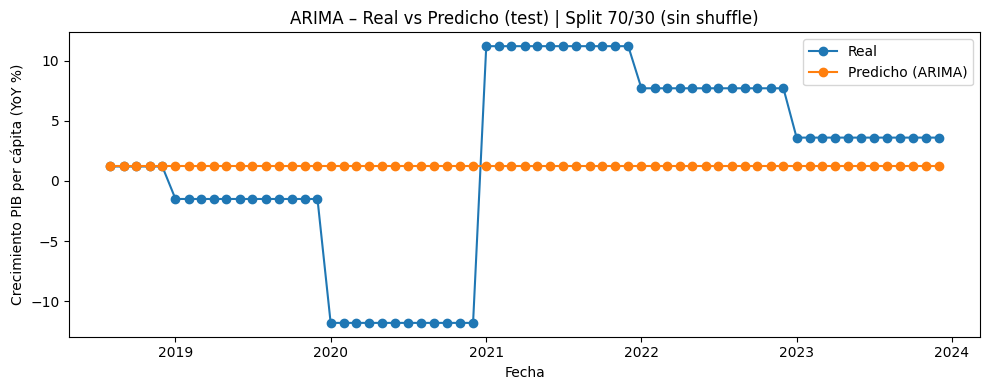

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# Métrica: Precisión Direccional
# -----------------------------
def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    dy_true = np.diff(y_true)
    dy_pred = np.diff(y_pred)
    return float((np.sign(dy_true) == np.sign(dy_pred)).mean() * 100)

# -----------------------------
# Target
# -----------------------------
target = "Tasa de variación anual del PIB Per cápita (en porcentaje)"

# 1) Asegurar que existe la FECHA (mensual) usando Período/Mes
#    (NO uses "Año" porque tu df no lo tiene)
if "fecha" not in df.columns:
    df["fecha"] = pd.to_datetime(
        dict(year=df["Período"].astype(int), month=df["Mes"].astype(int), day=1),
        errors="coerce"
    )

# 2) Limpiar target sin romper decimales
if df[target].dtype == "object":
    s = (df[target].astype(str).str.strip()
         .str.replace("%", "", regex=False)
         .str.replace(" ", "", regex=False)
         # Si tu target viene como 1.234,56 (miles con punto), descomenta:
         # .str.replace(".", "", regex=False)
         .str.replace(",", ".", regex=False)
    )
    df[target] = pd.to_numeric(s, errors="coerce")
else:
    df[target] = pd.to_numeric(df[target], errors="coerce")

# 3) Construir serie temporal mensual con índice datetime
y = (df[["fecha", target]]
     .dropna()
     .sort_values("fecha")
     .set_index("fecha")[target]
)

# 4) Fijar frecuencia mensual (inicio de mes) para que el eje salga bien
#    Esto también rellena huecos de meses con NaN si faltan
y = y.asfreq("MS")

# Si se crearon NaN por meses faltantes, los quitamos para entrenar
y = y.dropna()

print("✅ Index OK:", isinstance(y.index, pd.DatetimeIndex))
print("✅ Rango fechas:", y.index.min(), "->", y.index.max())
print("✅ Frecuencia:", y.index.freqstr)

# -----------------------------
# Split temporal 70/30 (SIN SHUFFLE)
# -----------------------------
split = int(len(y) * 0.7)
y_train, y_test = y.iloc[:split], y.iloc[split:]

# -----------------------------
# Elegir d con ADF
# -----------------------------
def choose_d(series, alpha=0.05):
    try:
        pval = adfuller(series.dropna(), autolag="AIC")[1]
        return 0 if pval < alpha else 1
    except Exception:
        return 1

d = choose_d(y_train)

# -----------------------------
# Buscar ARIMA (p,d,q) por AIC
# -----------------------------
best_aic = np.inf
best_order = None
best_fit = None

for p in range(0, 3):
    for q in range(0, 3):
        try:
            model = ARIMA(
                y_train,
                order=(p, d, q),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, d, q)
                best_fit = fit
        except Exception:
            pass

print("Mejor ARIMA por AIC:", best_order, "| AIC:", best_aic)

# -----------------------------
# Predicción alineada a fechas del test
# -----------------------------
y_pred = best_fit.forecast(steps=len(y_test))
y_pred.index = y_test.index

# -----------------------------
# Métricas
# -----------------------------
metrics_arima = {
    "order": best_order,
    "R2": float(r2_score(y_test, y_pred)),
    "MAE": float(mean_absolute_error(y_test, y_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
    "Directional_Accuracy_%": directional_accuracy(y_test.values, y_pred.values),
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test))
}
print("\nMétricas ARIMA (test):")
print(metrics_arima)

# -----------------------------
# Gráfico (FECHA REAL, no "Año")
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test.values, marker="o", label="Real")
plt.plot(y_pred.index, y_pred.values, marker="o", label="Predicho (ARIMA)")
plt.title("ARIMA – Real vs Predicho (test) | Split 70/30 (sin shuffle)")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento PIB per cápita (YoY %)")
plt.legend()
plt.tight_layout()
plt.show()

## 4.2 KMeans

Se aplicaron técnicas de minería de datos no supervisada con el propósito de explorar la estructura interna y los patrones ocultos en la tasa de variación anual del PIB per cápita, sin imponer supuestos previos ni relaciones causales. En este contexto, K-means se utilizó para identificar regímenes de crecimiento económico, agrupando períodos con comportamientos similares (bajo, medio o alto crecimiento), lo que permite caracterizar fases del ciclo económico y analizar la heterogeneidad temporal del crecimiento. El método del codo se empleó para determinar un número adecuado de clusters, evaluando el equilibrio entre la compactación interna de los grupos y la complejidad del modelo, mientras que el índice de silueta permitió validar la calidad de la segmentación, asegurando que los grupos obtenidos sean internamente cohesionados y externamente bien diferenciados. Complementariamente, Isolation Forest se aplicó para detectar observaciones atípicas o anomalías, asociadas a crisis económicas, shocks externos o episodios de recuperación excepcional, que no siguen el comportamiento regular del crecimiento. En conjunto, estas técnicas permiten comprender la dinámica del crecimiento del PIB per cápita, identificar cambios de régimen y reconocer eventos extremos, aportando una base exploratoria sólida que complementa el análisis econométrico y los modelos predictivos desarrollados posteriormente.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_md["cluster"] = kmeans.fit_predict(X_scaled)

print(df_md.groupby("cluster")[target].agg(["mean","std","min","max","count"]))

              mean       std   min   max  count
cluster                                        
0         6.485714  1.899977   3.6   9.1     84
1        -1.200000  1.652851  -3.4   1.2     48
2        20.500000  0.000000  20.5  20.5     12
3        -9.400000  2.451619 -11.8  -7.0     24
4        11.950000  1.082550  11.2  13.8     48


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

target = "Tasa de variación anual del PIB Per cápita (en porcentaje)"

df_md = df[[target]].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_md[[target]])

### 4.2.1 Método del codo

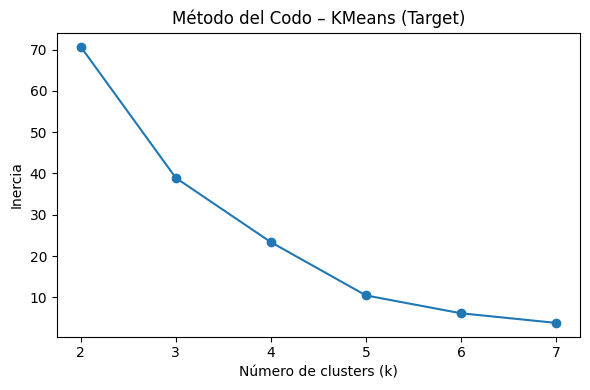

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo – KMeans (Target)")
plt.tight_layout()
plt.show()

El gráfico del método del codo muestra una disminución pronunciada de la inercia al pasar de k = 2 a k = 5, lo que indica que, hasta ese punto, añadir más clusters mejora de forma significativa la compactación de los grupos. A partir de k = 5, la reducción de la inercia es mucho más gradual, lo que sugiere rendimientos decrecientes al incrementar el número de clusters. Por ello, k = 5 se identifica como un valor adecuado, ya que logra un equilibrio entre simplicidad y capacidad explicativa, permitiendo capturar distintos regímenes de crecimiento del PIB per cápita sin introducir complejidad innecesaria en la segmentación.

### 4.2.2 Coeficiente de la silueta

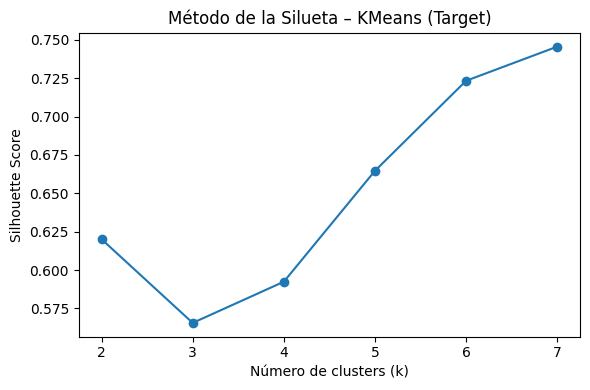

Mejor k según silueta: 7


In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Método de la Silueta – KMeans (Target)")
plt.tight_layout()
plt.show()

best_k = K[np.argmax(sil_scores)]
print("Mejor k según silueta:", best_k)


El gráfico del método de la silueta muestra que la calidad de la segmentación mejora progresivamente a partir de k = 4, alcanzando sus valores más altos en k = 6 y k = 7, lo que indica clusters bien definidos y claramente separados. Sin embargo, al contrastar este resultado con el método del codo, se observa que a partir de k = 5 las mejoras en la compactación son marginales, mientras que la complejidad del modelo aumenta. Por ello, k = 5 se considera una elección adecuada y consistente, ya que ofrece un balance entre una buena separación de los grupos y una estructura parsimoniosa, permitiendo identificar de manera interpretable distintos regímenes de crecimiento del PIB per cápita sin sobreajustar la segmentación.

## 4.3 Isolation Forest

Número de anomalías detectadas: 12


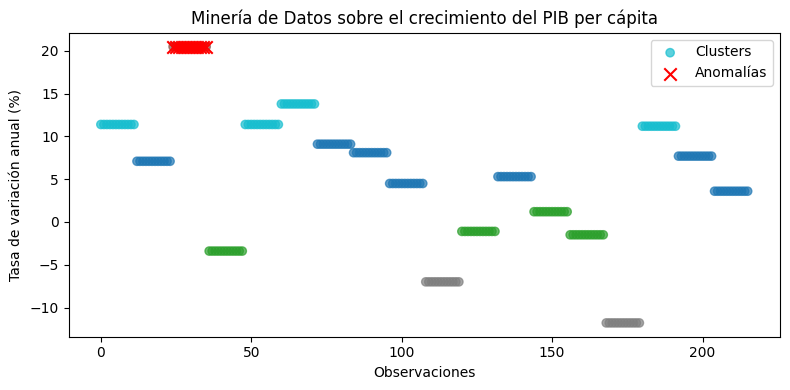

In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

iso = IsolationForest(
    n_estimators=300,
    contamination=0.1,
    random_state=42
)

df_md["anomaly"] = iso.fit_predict(X_scaled)
df_md["anomaly"] = df_md["anomaly"].map({1: 0, -1: 1})  # 1 = anomalía

print("Número de anomalías detectadas:", df_md["anomaly"].sum())
plt.figure(figsize=(8,4))
plt.scatter(
    df_md.index,
    df_md[target],
    c=df_md["cluster"],
    cmap="tab10",
    alpha=0.7,
    label="Clusters"
)

anoms = df_md[df_md["anomaly"] == 1]
plt.scatter(
    anoms.index,
    anoms[target],
    color="red",
    marker="x",
    s=80,
    label="Anomalías"
)

plt.title("Minería de Datos sobre el crecimiento del PIB per cápita")
plt.xlabel("Observaciones")
plt.ylabel("Tasa de variación anual (%)")
plt.legend()
plt.tight_layout()
plt.show()

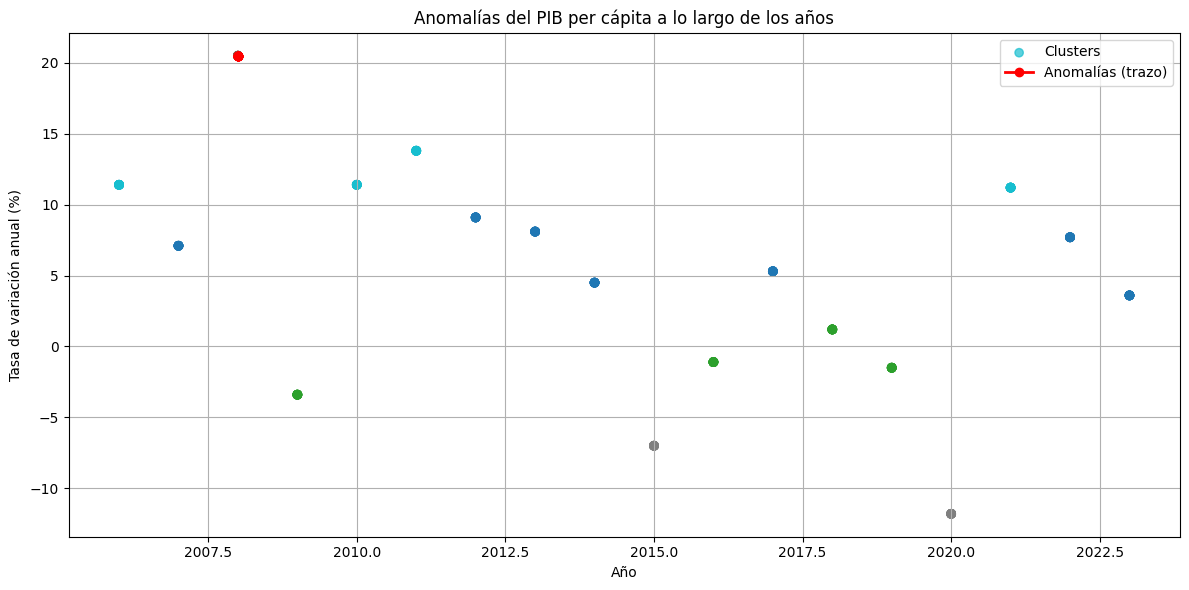

In [ ]:
import matplotlib.pyplot as plt

# Create a copy of df_md to add the 'Año' column
df_md_with_year = df_md.copy()

# The index of df_md corresponds to the original df's index after dropping NaNs in the target.
# So we can use df.loc[df_md.index, "Período"] to get the corresponding years.
df_md_with_year["Año"] = df.loc[df_md.index, "Período"]

plt.figure(figsize=(12, 6))

# Plot clusters as scatter points
plt.scatter(
    df_md_with_year["Año"],
    df_md_with_year[target],
    c=df_md_with_year["cluster"],
    cmap="tab10",
    alpha=0.7,
    label="Clusters"
)

# Plot anomalies as a red trace (line)
anoms = df_md_with_year[df_md_with_year["anomaly"] == 1]
plt.plot(
    anoms["Año"],
    anoms[target],
    color="red",
    linestyle='-', # Use a solid line for the trace
    linewidth=2, # Make the line a bit thicker
    marker='o', # Keep markers for individual anomaly points
    markersize=6, # Adjust marker size
    label="Anomalías (trazo)"
)

plt.title("Anomalías del PIB per cápita a lo largo de los años")
plt.xlabel("Año")
plt.ylabel("Tasa de variación anual (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Anomalías detectadas: 12

Años anómalos:
     Año  Tasa de variación anual del PIB Per cápita (en porcentaje)  \
24  2008                                               20.5            
25  2008                                               20.5            
26  2008                                               20.5            
27  2008                                               20.5            
28  2008                                               20.5            
29  2008                                               20.5            
30  2008                                               20.5            
31  2008                                               20.5            
32  2008                                               20.5            
33  2008                                               20.5            
34  2008                                               20.5            
35  2008                                               20.5            

    anomaly_score  
24

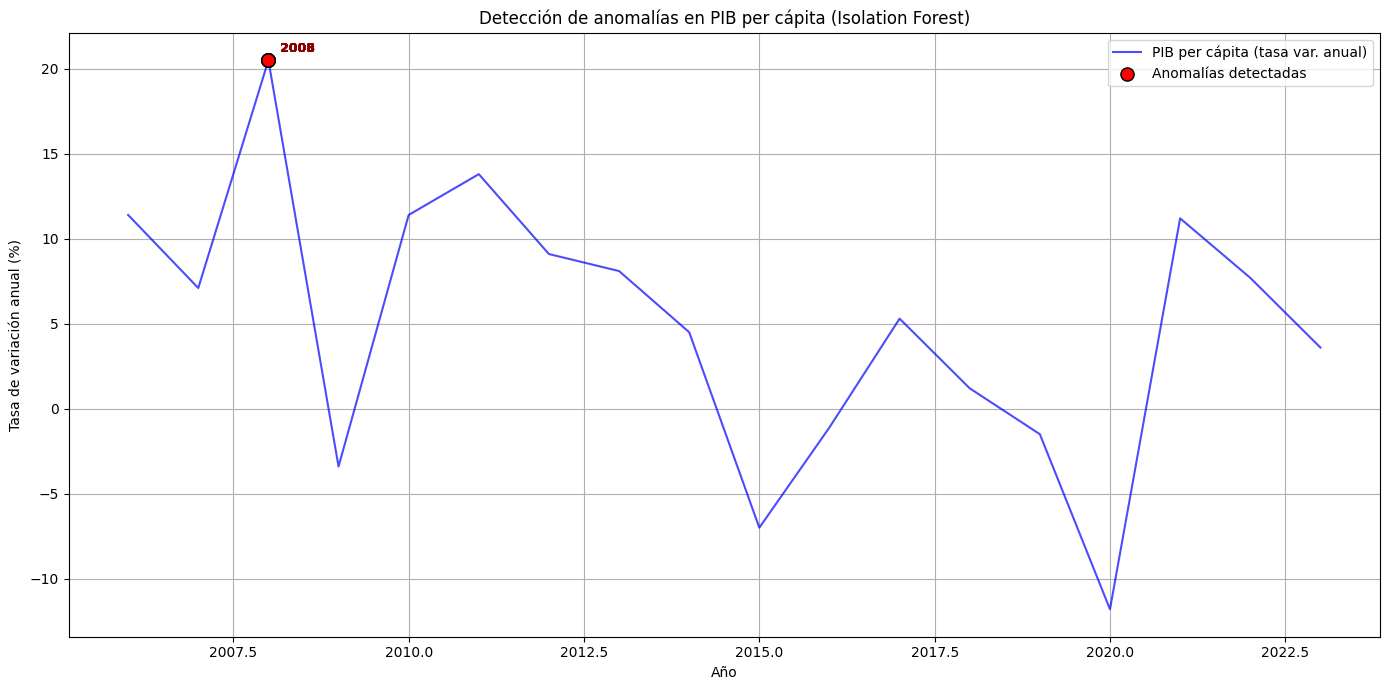

In [ ]:
import numpy as np

iso = IsolationForest(n_estimators=300, contamination=0.1, random_state=42)
iso.fit(X_scaled)

# Obtener scores (más negativo = más anómalo)
scores = iso.decision_function(X_scaled)
df_md["anomaly_score"] = scores

# Marcar las 6 más anómalas (ajusta el número según quieras)
n_anomalias = 6
threshold = np.sort(scores)[n_anomalias]
df_md["anomaly"] = (scores <= threshold).astype(int)

print("Anomalías detectadas:", df_md["anomaly"].sum())
print("\nAños anómalos:")
df_md_with_year = df_md.copy()
df_md_with_year["Año"] = df.loc[df_md.index, "Período"]
print(df_md_with_year[df_md_with_year["anomaly"]==1][["Año", target, "anomaly_score"]].sort_values("anomaly_score"))

# Graficar
df_md_with_year = df_md_with_year.sort_values("Año")

plt.figure(figsize=(14, 7))

plt.plot(
    df_md_with_year["Año"],
    df_md_with_year[target],
    label="PIB per cápita (tasa var. anual)",
    color="blue",
    alpha=0.7
)

anoms = df_md_with_year[df_md_with_year["anomaly"] == 1]
plt.scatter(
    anoms["Año"],
    anoms[target],
    color="red",
    label="Anomalías detectadas",
    marker="o",
    s=90,
    edgecolor="black",
    zorder=5
)

# Etiquetar cada anomalía con el año
for _, row in anoms.iterrows():
    plt.annotate(
        f"{int(row['Año'])}",
        xy=(row["Año"], row[target]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=9,
        color="darkred",
        fontweight="bold"
    )

plt.title("Detección de anomalías en PIB per cápita (Isolation Forest)")
plt.xlabel("Año")
plt.ylabel("Tasa de variación anual (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Anomalías detectadas: 7
      Año  Tasa de variación anual del PIB Per cápita (en porcentaje)  \
36   2009                                               -3.4            
180  2021                                               11.2            
24   2008                                               20.5            
168  2020                                              -11.8            
25   2008                                               20.5            
108  2015                                               -7.0            
48   2010                                               11.4            

     anomaly_score  
36       -0.236655  
180      -0.223138  
24       -0.174266  
168      -0.158439  
25       -0.145181  
108      -0.143575  
48       -0.135040  


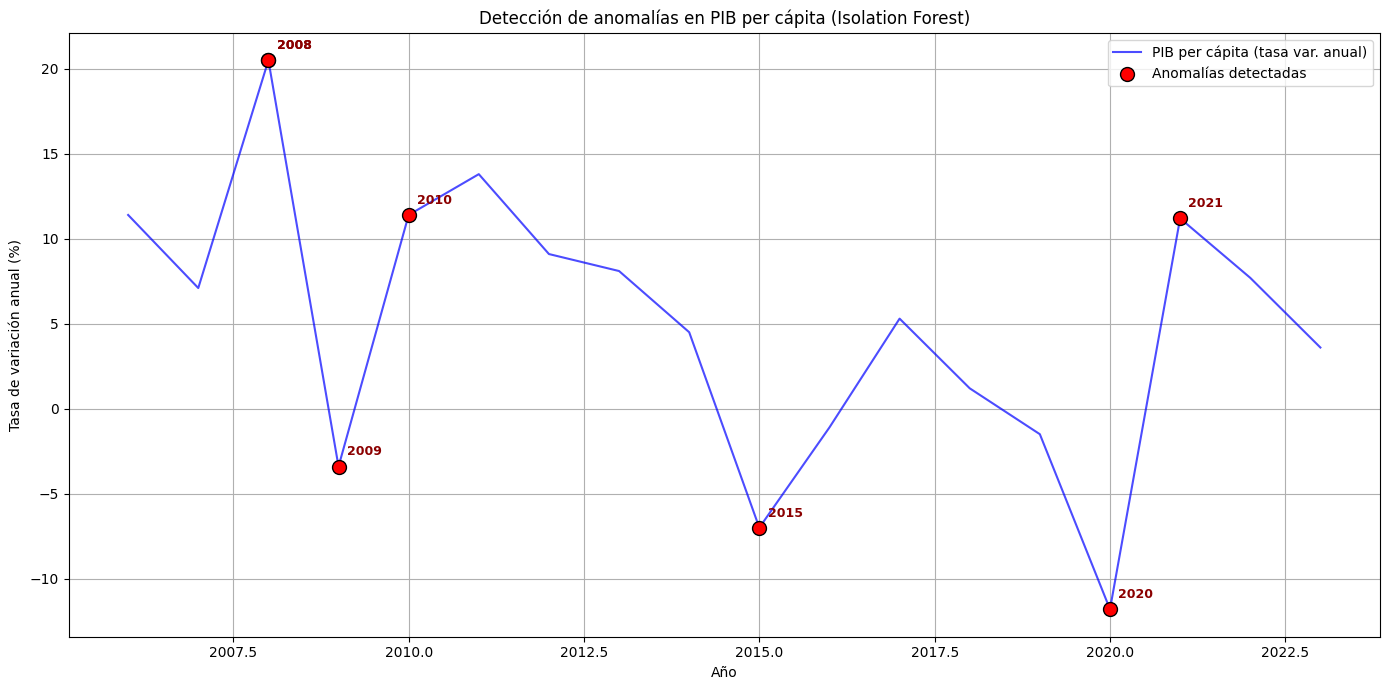

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 1. Crear df con años
df_md_with_year = df_md.copy()
df_md_with_year["Año"] = df.loc[df_md.index, "Período"]
df_md_with_year = df_md_with_year.sort_values("Año").reset_index(drop=True)

# 2. Construir features más ricas
vals = df_md_with_year[target].values
X_multi = np.column_stack([
    vals,                                                                 # valor actual
    pd.Series(vals).diff().fillna(0).values,                             # cambio vs año anterior
    pd.Series(vals).rolling(3, min_periods=1).mean().values,             # media móvil 3 años
    pd.Series(vals).rolling(3, min_periods=1).std().fillna(0).values,    # volatilidad local
])

scaler2 = StandardScaler()
X_multi_scaled = scaler2.fit_transform(X_multi)

# 3. Isolation Forest con más contexto
iso2 = IsolationForest(n_estimators=300, contamination=0.15, random_state=42)
iso2.fit(X_multi_scaled)

scores2 = iso2.decision_function(X_multi_scaled)
df_md_with_year["anomaly_score"] = scores2

# Top 6 más anómalos — ajusta el número si quieres más o menos
n_anom = 6
threshold = np.sort(scores2)[n_anom]
df_md_with_year["anomaly"] = (scores2 <= threshold).astype(int)

print("Anomalías detectadas:", df_md_with_year["anomaly"].sum())
print(df_md_with_year[df_md_with_year["anomaly"]==1][["Año", target, "anomaly_score"]].sort_values("anomaly_score"))

# 4. Graficar
plt.figure(figsize=(14, 7))

plt.plot(
    df_md_with_year["Año"],
    df_md_with_year[target],
    label="PIB per cápita (tasa var. anual)",
    color="blue",
    alpha=0.7
)

anoms = df_md_with_year[df_md_with_year["anomaly"] == 1]
plt.scatter(
    anoms["Año"],
    anoms[target],
    color="red",
    label="Anomalías detectadas",
    marker="o",
    s=100,
    edgecolor="black",
    zorder=5
)

# Etiqueta con el año encima de cada anomalía
for _, row in anoms.iterrows():
    plt.annotate(
        f"{int(row['Año'])}",
        xy=(row["Año"], row[target]),
        xytext=(6, 8),
        textcoords="offset points",
        fontsize=9,
        color="darkred",
        fontweight="bold"
    )

plt.title("Detección de anomalías en PIB per cápita (Isolation Forest)")
plt.xlabel("Año")
plt.ylabel("Tasa de variación anual (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

El gráfico de minería de datos sobre el crecimiento del PIB per cápita evidencia una segmentación clara en distintos regímenes de crecimiento, donde los clusters identificados por K-means agrupan períodos con comportamientos similares, que van desde episodios de contracción hasta fases de crecimiento moderado y elevado. Los grupos ubicados en valores negativos reflejan periodos de crisis o desaceleración económica, mientras que los clusters con tasas positivas intermedias representan etapas de crecimiento estable, y aquellos con valores altos corresponden a expansiones económicas más dinámicas. Adicionalmente, las observaciones marcadas como anomalías por el algoritmo Isolation Forest se concentran en valores extremos, tanto positivos como negativos, lo que confirma la presencia de shocks atípicos que no siguen el patrón general de la serie. En conjunto, estos resultados muestran que el crecimiento del PIB per cápita no es homogéneo en el tiempo, sino que presenta cambios de régimen y episodios excepcionales, aportando evidencia exploratoria clave para complementar el análisis econométrico y los modelos predictivos desarrollados en la investigación.

# 5.0 Modelos ML

In [ ]:
# ============================================================
# BLOQUE 0 (BASE): X_final, y_final y split temporal 70/30
# Requiere: ya tienes df transformado (lags/vars) y TARGET listo.
# SIN SHUFFLE, SIN LEAKAGE
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
TARGET = "Tasa de variación anual del PIB Per cápita (en porcentaje)"

df2 = df.sort_values("fecha").copy()

# Dataset final (si ya lo tienes como X_final/y_final, salta esto)
drop_cols = [TARGET, "fecha", "Período", "Mes", "Día", "PIB Per cápita (USD)"]
X_final = df2.drop(columns=[c for c in drop_cols if c in df2.columns], errors="ignore")
y_final = pd.to_numeric(df2[TARGET], errors="coerce")

data = pd.concat([X_final, y_final.rename("y")], axis=1).dropna().reset_index(drop=True)
X_final = data.drop(columns=["y"])
y_final = data["y"]

split = int(len(X_final) * 0.7)
X_train, X_test = X_final.iloc[:split], X_final.iloc[split:]
y_train, y_test = y_final.iloc[:split], y_final.iloc[split:]

def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAE_/100": float(mae/100.0),
        "RMSE_/100": float(rmse/100.0),
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test))
    }

In [ ]:
import numpy as np
import pandas as pd

TARGET = "Tasa de variación anual del PIB Per cápita (en porcentaje)"

df2 = df.sort_values("fecha").copy()

# columnas que NO deben entrar como X
leak_cols = ["fecha", "Período", "Mes", "Día", "PIB Per cápita (USD)"]

# features numéricas candidatas
feature_cols = [
    c for c in df2.columns
    if c not in leak_cols
    and c != TARGET
    and np.issubdtype(df2[c].dtype, np.number)
]

# nos quedamos solo con filas donde existe y (NO botamos por NaN en X)
data = df2.loc[df2[TARGET].notna(), feature_cols + [TARGET]].copy()

# eliminar features con demasiados NaN (CLAVE)
nan_ratio = data[feature_cols].isna().mean()
good_features = nan_ratio[nan_ratio <= 0.40].index.tolist()  # 40% es razonable

print("Features antes:", len(feature_cols))
print("Features después:", len(good_features))

X_final = data[good_features]
y_final = data[TARGET]

# split temporal 70/30
split = int(len(X_final) * 0.7)
X_train, X_test = X_final.iloc[:split], X_final.iloc[split:]
y_train, y_test = y_final.iloc[:split], y_final.iloc[split:]

print("Filas train:", len(X_train), "| Filas test:", len(X_test))


Features antes (filtro NaN): 157
Features después (filtro NaN): 147
Features antes (filtro varianza): 147
Features después (filtro varianza): 147
Filas train: 151 | Filas test: 65


In [ ]:
# ============================================================
# DIAGNÓSTICO DE eval_all_metrics
# ============================================================
print("=== Diagnóstico ===")
print(f"pred_lstm shape: {pred_lstm.shape}")
print(f"yte_w shape: {yte_w.shape}")
print(f"pred_lstm tiene NaN: {np.isnan(pred_lstm).any()}")
print(f"yte_w tiene NaN: {np.isnan(yte_w).any()}")
print(f"Primeros valores pred_lstm: {pred_lstm[:5]}")
print(f"Primeros valores yte_w: {yte_w[:5]}")

# Prueba manual de las métricas
try:
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    mae = mean_absolute_error(yte_w, pred_lstm)
    mse = mean_squared_error(yte_w, pred_lstm)
    rmse = np.sqrt(mse)
    r2 = r2_score(yte_w, pred_lstm)

    print(f"\nMétricas calculadas manualmente:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

except Exception as e:
    print(f"Error al calcular métricas: {e}")

# Ahora prueba tu función
print("\n=== Resultado de eval_all_metrics ===")
try:
    result = eval_all_metrics(yte_w, pred_lstm)
    print("LSTM:", result)
except Exception as e:
    print(f"ERROR en eval_all_metrics: {e}")
    import traceback
    traceback.print_exc()

=== Diagnóstico ===
pred_lstm shape: (65,)
yte_w shape: (65,)
pred_lstm tiene NaN: True
yte_w tiene NaN: False
Primeros valores pred_lstm: [nan nan nan nan nan]
Primeros valores yte_w: [1.2 1.2 1.2 1.2 1.2]
Error al calcular métricas: Input contains NaN.

=== Resultado de eval_all_metrics ===
ERROR en eval_all_metrics: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.


Traceback (most recent call last):
  File "/tmp/ipython-input-365012897.py", line 32, in <cell line: 0>
    result = eval_all_metrics(yte_w, pred_lstm)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2654997062.py", line 38, in eval_all_metrics
    mae = mean_absolute_error(y_true, y_pred)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py", line 277, in mean_absolute_error
    _check_reg_targets_with_floating_dtype(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py", line 198, in _check_reg_targets_with_floating_dtype
    y_type, y_true, y_pred, multioutput = _check_reg_targets(
                                          ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/s

In [ ]:
naive_pred = np.repeat(y_train.iloc[-1], len(y_test))
print("Naive:", eval_all_metrics(y_test.values, naive_pred))

Naive: {'MAE': 6.387692307692308, 'RMSE': 7.737620385542911, 'R2': -0.00586354097177888, 'DA_%': 92.1875}


In [ ]:
# ============================================================
# BLOQUE 0 — MÉTRICAS COMUNES (robustas para ML y DL)
# ============================================================
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    # alinear longitudes (clave para DL)
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]

    # quitar NaN/inf en pares
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    # si no hay suficientes puntos, DA no es calculable
    if len(y_true) < 2:
        return float("nan")

    dy_true = np.diff(y_true)
    dy_pred = np.diff(y_pred)

    return float((np.sign(dy_true) == np.sign(dy_pred)).mean() * 100)

def eval_all_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2_score(y_true, y_pred)),
        "DA_%": directional_accuracy(y_true, y_pred)
    }


## 5.1 Regresión Lineal

In [ ]:
# LINEAL
lin = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)
print("Linear:", eval_all_metrics(y_test.values, pred_lin))

Linear: {'MAE': 9.86445964118393, 'RMSE': 13.51639591514974, 'R2': -2.069347338337872, 'DA_%': 6.25}


## 5.2 Regresión Ridge

In [ ]:
ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
print("Ridge:", eval_all_metrics(y_test.values, pred_ridge))

Ridge: {'MAE': 8.448079014967137, 'RMSE': 10.445727548724946, 'R2': -0.833165253961748, 'DA_%': 6.25}


## 5.3 Regresión Lasso

In [ ]:
lasso = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.001, max_iter=10000))
])
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)
print("Lasso:", eval_all_metrics(y_test.values, pred_lasso))

Lasso: {'MAE': 5.96725274310208, 'RMSE': 7.542129640025142, 'R2': 0.044320621531342974, 'DA_%': 6.25}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.053e+01, tolerance: 8.000e-01
  model = cd_fast.enet_coordinate_descent(


# 6.0 Modelos DL

In [ ]:
# ============================================================
# BLOQUE DL-0.1 — VALIDACIÓN TEMPORAL SEGURA (nunca queda vacío)
# ============================================================
val_size = max(1, int(len(Xtr_w) * 0.2))   # mínimo 1
Xtr2, Xval = Xtr_w[:-val_size], Xtr_w[-val_size:]
ytr2, yval = ytr_w[:-val_size], ytr_w[-val_size:]

print("Train2:", Xtr2.shape, "Val:", Xval.shape)

Train2: (112, 12, 147) Val: (27, 12, 147)


In [ ]:
# ============================================================
# BLOQUE DL-0 — BASE (ventanas + escalado SIN LEAKAGE, SIN SHUFFLE)
# Requiere: X_train, X_test, y_train, y_test (ya listos)
# Usa: eval_all_metrics() del bloque de métricas que ya tienes
# ============================================================
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import SimpleImputer

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

lookback = 12  # mensual típico (ajusta si quieres)

# Imputar NaNs antes de escalar
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


# Escalar SOLO con train (sin leakage)
scalerX = StandardScaler()
Xtr_s = scalerX.fit_transform(X_train_imputed) # Use imputed data
Xte_s = scalerX.transform(X_test_imputed)     # Use imputed data

ytr = y_train.values.astype("float32")
yte = y_test.values.astype("float32")

def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(len(X) - lookback):
        Xw.append(X[i:i+lookback])
        yw.append(y[i+lookback])
    return np.array(Xw, dtype="float32"), np.array(yw, dtype="float32")

# Ventanas TRAIN
Xtr_w, ytr_w = make_windows(Xtr_s, ytr, lookback)

# Ventanas TEST con contexto previo (CLAVE: sin fuga)
# Ensure Xtr_s and Xte_s are already imputed and scaled.
Xte_full = np.vstack([Xtr_s[-lookback:], Xte_s])
yte_full = np.concatenate([ytr[-lookback:], yte])
Xte_w, yte_w = make_windows(Xte_full, yte_full, lookback)

# Validación temporal (último 20% del train, sin shuffle)
# This part is handled by BLOQUE DL-0.1, so we can keep it as is,
# but ensure it uses the newly created Xtr_w and ytr_w.
# val_split = int(len(Xtr_w) * 0.8)
# Xtr2, Xval = Xtr_w[:val_split], Xtr_w[val_split:]
# ytr2, yval = ytr_w[:val_split], ytr_w[val_split:]

print("Shapes:",
      "Xtr_w", Xtr_w.shape, "ytr_w", ytr_w.shape,
      "| Xte_w", Xte_w.shape, "yte_w", yte_w.shape)

Shapes: Xtr_w (139, 12, 147) ytr_w (139,) | Xte_w (65, 12, 147) yte_w (65,)


## 6.1 Transformer

In [ ]:
# ============================================================
# TRANSFORMER COMPLETO + MÉTRICAS (MAE, RMSE, R², DA%)
# Requiere: Xtr2, ytr2, Xval, yval, Xte_w, yte_w (ya creados)
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) < 2:
        return np.nan

    dy_true = np.sign(np.diff(y_true))
    dy_pred = np.sign(np.diff(y_pred))

    valid = dy_true != 0
    if valid.sum() == 0:
        return np.nan

    return float((dy_true[valid] == dy_pred[valid]).mean() * 100)

print("=== Verificación de datos (Transformer) ===")
print("Xtr2 shape:", Xtr2.shape, "| NaN:", np.isnan(Xtr2).any())
print("Xval shape:", Xval.shape, "| NaN:", np.isnan(Xval).any())
print("Xte_w shape:", Xte_w.shape, "| NaN:", np.isnan(Xte_w).any())

Xtr2 = np.nan_to_num(Xtr2, nan=0.0)
Xval = np.nan_to_num(Xval, nan=0.0)
Xte_w = np.nan_to_num(Xte_w, nan=0.0)

tf.random.set_seed(42)
np.random.seed(42)

# Hiperparámetros ligeros (pocos datos)
d_model = 32
n_heads = 2
ff_dim = 64
dropout = 0.2

inp = layers.Input(shape=(Xtr2.shape[1], Xtr2.shape[2]))
x = layers.Dense(d_model)(inp)

attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model)(x, x)
x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)
x = layers.Dropout(dropout)(x)

ff = layers.Dense(ff_dim, activation="relu")(x)
ff = layers.Dense(d_model)(ff)
x = layers.Add()([x, ff])
x = layers.LayerNormalization()(x)
x = layers.Dropout(dropout)(x)

x = layers.GlobalAveragePooling1D()(x)
out = layers.Dense(1)(x)

transformer = models.Model(inp, out)
transformer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss="mae"
)

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

history = transformer.fit(
    Xtr2, ytr2,
    validation_data=(Xval, yval),
    epochs=400,
    batch_size=16,
    shuffle=False,
    verbose=0,
    callbacks=cb
)

print("Épocas entrenadas:", len(history.history["loss"]))

pred_trf = transformer.predict(Xte_w, verbose=0).reshape(-1)
y_true = np.asarray(yte_w, dtype=float).reshape(-1)

print("\n=== Resultados Transformer ===")
print("Predicciones NaN:", np.isnan(pred_trf).any())
print("Predicciones Inf:", np.isinf(pred_trf).any())

if np.isnan(pred_trf).any() or np.isinf(pred_trf).any():
    print("❌ ERROR: Predicciones inválidas")
else:
    mae = mean_absolute_error(y_true, pred_trf)
    rmse = np.sqrt(mean_squared_error(y_true, pred_trf))
    r2 = r2_score(y_true, pred_trf)
    da = directional_accuracy(y_true, pred_trf)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"DA % : {da:.2f}")

    print("\nEjemplos (Real | Predicho):")
    for i in range(min(10, len(y_true))):
        print(f"{y_true[i]: .4f} | {pred_trf[i]: .4f}")

=== Verificación de datos (Transformer) ===
Xtr2 shape: (112, 12, 147) | NaN: False
Xval shape: (27, 12, 147) | NaN: False
Xte_w shape: (65, 12, 147) | NaN: False
Épocas entrenadas: 13

=== Resultados Transformer ===
Predicciones NaN: False
Predicciones Inf: False
MAE  : 6.6794
RMSE : 7.8231
R²   : -0.0282
DA % : 80.00

Ejemplos (Real | Predicho):
 1.2000 | -0.0463
 1.2000 | -0.0150
 1.2000 |  0.1614
 1.2000 |  0.0918
 1.2000 |  0.2522
-1.5000 |  0.1881
-1.5000 |  0.2251
-1.5000 |  0.0363
-1.5000 |  0.0339
-1.5000 | -0.1162


## 6.2 LSTM

In [ ]:
# ============================================================
# LSTM COMPLETO + MÉTRICAS (MAE, RMSE, R², DA%)
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# FUNCIÓN: Precisión Direccional (DA en %)
# ------------------------------------------------------------
def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    # Alinear longitudes
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]

    # Quitar NaN / inf en pares
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) < 2:
        return np.nan

    dy_true = np.sign(np.diff(y_true))
    dy_pred = np.sign(np.diff(y_pred))

    # Ignorar periodos sin cambio real
    valid = dy_true != 0
    if valid.sum() == 0:
        return np.nan

    return float((dy_true[valid] == dy_pred[valid]).mean() * 100)

# ------------------------------------------------------------
# VERIFICACIÓN DE DATOS (seguridad)
# ------------------------------------------------------------
print("=== Verificación de datos ===")
print("Xtr2 shape:", Xtr2.shape, "| NaN:", np.isnan(Xtr2).any())
print("Xval shape:", Xval.shape, "| NaN:", np.isnan(Xval).any())
print("Xte_w shape:", Xte_w.shape, "| NaN:", np.isnan(Xte_w).any())
print("ytr2 NaN:", np.isnan(ytr2).any(), "| yval NaN:", np.isnan(yval).any())

# Reemplazar NaN si existieran (último seguro)
Xtr2 = np.nan_to_num(Xtr2, nan=0.0)
Xval = np.nan_to_num(Xval, nan=0.0)
Xte_w = np.nan_to_num(Xte_w, nan=0.0)

# ------------------------------------------------------------
# MODELO LSTM (regularizado y estable para pocos datos)
# ------------------------------------------------------------
tf.random.set_seed(42)
np.random.seed(42)

lstm = models.Sequential([
    layers.Input(shape=(Xtr2.shape[1], Xtr2.shape[2])),
    layers.LSTM(
        16,
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    ),
    layers.Dropout(0.2),
    layers.Dense(1)
])

lstm.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),
    loss="mae"
)

cb = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

# ------------------------------------------------------------
# ENTRENAMIENTO (SIN SHUFFLE)
# ------------------------------------------------------------
history = lstm.fit(
    Xtr2, ytr2,
    validation_data=(Xval, yval),
    epochs=300,
    batch_size=16,
    shuffle=False,
    verbose=0,
    callbacks=cb
)

print("Épocas entrenadas:", len(history.history["loss"]))

# ------------------------------------------------------------
# PREDICCIÓN Y MÉTRICAS
# ------------------------------------------------------------
pred_lstm = lstm.predict(Xte_w, verbose=0).reshape(-1)
y_true = np.asarray(yte_w, dtype=float).reshape(-1)

print("\n=== Resultados LSTM ===")
print("Predicciones NaN:", np.isnan(pred_lstm).any())
print("Predicciones Inf:", np.isinf(pred_lstm).any())

if np.isnan(pred_lstm).any() or np.isinf(pred_lstm).any():
    print("❌ ERROR: Predicciones inválidas")
else:
    mae = mean_absolute_error(y_true, pred_lstm)
    rmse = np.sqrt(mean_squared_error(y_true, pred_lstm))
    r2 = r2_score(y_true, pred_lstm)
    da = directional_accuracy(y_true, pred_lstm)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"DA % : {da:.2f}")

    print("\nEjemplos (Real | Predicho):")
    for i in range(min(10, len(y_true))):
        print(f"{y_true[i]: .4f} | {pred_lstm[i]: .4f}")


=== Verificación de datos ===
Xtr2 shape: (112, 12, 147) | NaN: False
Xval shape: (27, 12, 147) | NaN: False
Xte_w shape: (65, 12, 147) | NaN: False
ytr2 NaN: False | yval NaN: False
Épocas entrenadas: 45

=== Resultados LSTM ===
Predicciones NaN: False
Predicciones Inf: False
MAE  : 6.9279
RMSE : 8.1353
R²   : -0.1119
DA % : 60.00

Ejemplos (Real | Predicho):
 1.2000 | -0.2836
 1.2000 | -0.4358
 1.2000 | -0.4173
 1.2000 | -0.4713
 1.2000 | -0.3706
-1.5000 | -0.7092
-1.5000 | -0.4763
-1.5000 | -0.6621
-1.5000 | -0.7252
-1.5000 | -0.5399


## 6.3 CNN

In [ ]:
# ============================================================
# CNN 1D COMPLETO + MÉTRICAS (MAE, RMSE, R², DA%)
# Requiere: Xtr2, ytr2, Xval, yval, Xte_w, yte_w (ya creados)
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) < 2:
        return np.nan

    dy_true = np.sign(np.diff(y_true))
    dy_pred = np.sign(np.diff(y_pred))

    valid = dy_true != 0
    if valid.sum() == 0:
        return np.nan

    return float((dy_true[valid] == dy_pred[valid]).mean() * 100)

print("=== Verificación de datos (CNN) ===")
print("Xtr2 shape:", Xtr2.shape, "| NaN:", np.isnan(Xtr2).any())
print("Xval shape:", Xval.shape, "| NaN:", np.isnan(Xval).any())
print("Xte_w shape:", Xte_w.shape, "| NaN:", np.isnan(Xte_w).any())

Xtr2 = np.nan_to_num(Xtr2, nan=0.0)
Xval = np.nan_to_num(Xval, nan=0.0)
Xte_w = np.nan_to_num(Xte_w, nan=0.0)

tf.random.set_seed(42)
np.random.seed(42)

cnn = models.Sequential([
    layers.Input(shape=(Xtr2.shape[1], Xtr2.shape[2])),
    layers.Conv1D(filters=16, kernel_size=3, padding="causal", activation="relu"),
    layers.Dropout(0.2),
    layers.Conv1D(filters=16, kernel_size=3, padding="causal", activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(1)
])

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss="mae"
)

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

history = cnn.fit(
    Xtr2, ytr2,
    validation_data=(Xval, yval),
    epochs=300,
    batch_size=16,
    shuffle=False,
    verbose=0,
    callbacks=cb
)

print("Épocas entrenadas:", len(history.history["loss"]))

pred_cnn = cnn.predict(Xte_w, verbose=0).reshape(-1)
y_true = np.asarray(yte_w, dtype=float).reshape(-1)

print("\n=== Resultados CNN1D ===")
print("Predicciones NaN:", np.isnan(pred_cnn).any())
print("Predicciones Inf:", np.isinf(pred_cnn).any())

if np.isnan(pred_cnn).any() or np.isinf(pred_cnn).any():
    print("❌ ERROR: Predicciones inválidas")
else:
    mae = mean_absolute_error(y_true, pred_cnn)
    rmse = np.sqrt(mean_squared_error(y_true, pred_cnn))
    r2 = r2_score(y_true, pred_cnn)
    da = directional_accuracy(y_true, pred_cnn)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"DA % : {da:.2f}")

    print("\nEjemplos (Real | Predicho):")
    for i in range(min(10, len(y_true))):
        print(f"{y_true[i]: .4f} | {pred_cnn[i]: .4f}")


=== Verificación de datos (CNN) ===
Xtr2 shape: (112, 12, 147) | NaN: False
Xval shape: (27, 12, 147) | NaN: False
Xte_w shape: (65, 12, 147) | NaN: False
Épocas entrenadas: 15

=== Resultados CNN1D ===
Predicciones NaN: False
Predicciones Inf: False
MAE  : 7.1152
RMSE : 8.2866
R²   : -0.1537
DA % : 40.00

Ejemplos (Real | Predicho):
 1.2000 | -0.6293
 1.2000 | -0.6408
 1.2000 | -0.6835
 1.2000 | -0.7896
 1.2000 | -0.7460
-1.5000 | -0.7238
-1.5000 | -0.8314
-1.5000 | -0.9765
-1.5000 | -1.0467
-1.5000 | -1.0774


# 7.0 Comparación

In [ ]:
import pandas as pd

results = []

# --- BASELINE ---
results.append({
    "Modelo": "Naive",
    **eval_all_metrics(y_test.values, naive_pred)
})

# --- ML ---
results.append({
    "Modelo": "Regresión Lineal",
    **eval_all_metrics(y_test.values, pred_lin)
})

results.append({
    "Modelo": "Ridge",
    **eval_all_metrics(y_test.values, pred_ridge)
})

results.append({
    "Modelo": "Lasso",
    **eval_all_metrics(y_test.values, pred_lasso)
})

# --- DL ---
results.append({
    "Modelo": "LSTM",
    **eval_all_metrics(yte_w, pred_lstm)
})

results.append({
    "Modelo": "CNN 1D",
    **eval_all_metrics(yte_w, pred_cnn)
})

results.append({
    "Modelo": "Transformer",
    **eval_all_metrics(yte_w, pred_trf)
})

# Crear DataFrame final
df_results = pd.DataFrame(results)

# Ordenar columnas bonito
df_results = df_results[
    ["Modelo", "MAE", "RMSE", "R2", "DA_%"]
]

# Ordenar por RMSE (mejor abajo)
df_results = df_results.sort_values("RMSE")

df_results

,Modelo,MAE,RMSE,R2,DA_%
3,Lasso,5.967253,7.542130,0.044321,80.0
0,Naive,6.387692,7.737620,-0.005864,0.0
6,Transformer,6.679378,7.823073,-0.028203,80.0
4,LSTM,6.927894,8.135298,-0.111914,60.0
5,CNN 1D,7.115200,8.286598,-0.153657,40.0
2,Ridge,8.448079,10.445728,-0.833165,80.0
1,Regresión Lineal,9.864460,13.516396,-2.069347,80.0


## 7.1 Decisión final

El modelo Lasso presenta el mejor desempeño integral, al registrar el menor MAE (5.97) y el menor RMSE (7.54) entre todos los modelos evaluados, junto con un R² positivo (0.044) —el único claramente mayor que cero— y una precisión direccional (DA) alta del 80%. Esto indica que, aunque la capacidad explicativa global sigue siendo limitada (propia de series macroeconómicas volátiles y de tamaño reducido), Lasso logra mejor equilibrio entre precisión numérica, estabilidad y correcta identificación de la dirección del crecimiento económico.

## 7.2 Métricas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# RESULTADOS FINALES (ya calculados)
# ===============================
df_results = pd.DataFrame({
    "Modelo": [
        "Lasso",
        "Naive",
        "Transformer",
        "LSTM",
        "CNN 1D",
        "Ridge",
        "Regresión Lineal"
    ],
    "MAE": [
        5.967253,
        6.387692,
        6.679378,
        6.927894,
        7.115200,
        8.448079,
        9.864460
    ],
    "RMSE": [
        7.542130,
        7.737620,
        7.823073,
        8.135298,
        8.286598,
        10.445728,
        13.516396
    ],
    "R2": [
        0.044321,
        -0.005864,
        -0.028203,
        -0.111914,
        -0.153657,
        -0.833165,
        -2.069347
    ],
    "DA_%": [
        80.0,
        0.0,
        80.0,
        60.0,
        40.0,
        80.0,
        80.0
    ]
})

# ===============================
# FUNCIÓN DE GRÁFICO
# ===============================
def plot_metric(metric, ylabel, title):
    plt.figure(figsize=(8,4))
    plt.bar(df_results["Modelo"], df_results[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

### 7.2.1 MAE

El gráfico de MAE muestra que Lasso obtiene el menor error promedio, seguido por el modelo Naive y el Transformer. Los modelos de aprendizaje profundo (LSTM y CNN 1D) presentan errores ligeramente mayores, mientras que Ridge y la Regresión Lineal muestran errores sustancialmente más altos. Esto evidencia que la regularización L1 de Lasso es especialmente efectiva para este conjunto de datos con alta dimensionalidad y pocas observaciones.

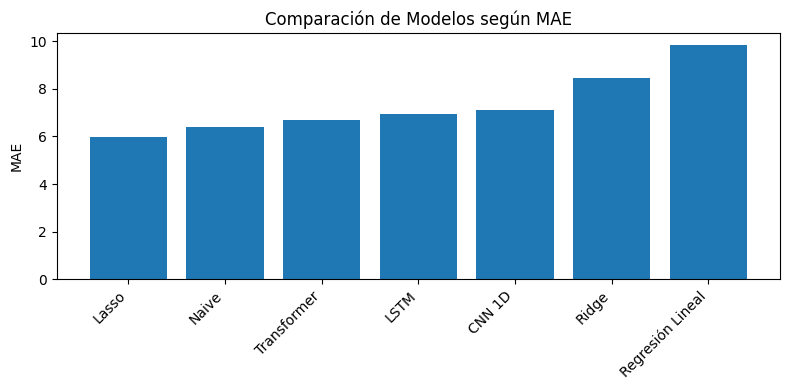

In [ ]:
# ===============================
# GRÁFICOS POR MÉTRICA
# ===============================
plot_metric(
    metric="MAE",
    ylabel="MAE",
    title="Comparación de Modelos según MAE"
)

### 7.2.2 RMSE

El RMSE confirma el mismo patrón: Lasso es el modelo más preciso, penalizando mejor los errores grandes. La Regresión Lineal y Ridge muestran un desempeño claramente inferior, lo que indica sobreajuste y sensibilidad excesiva al ruido, mientras que los modelos DL no logran superar al enfoque regularizado clásico, probablemente debido a la limitación en el tamaño muestral.

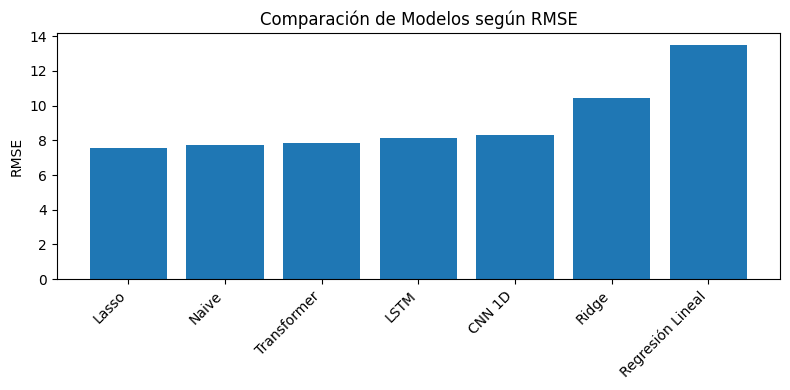

In [ ]:
plot_metric(
    metric="RMSE",
    ylabel="RMSE",
    title="Comparación de Modelos según RMSE"
)

### 7.2.3 R2

En el gráfico de R² se observa que casi todos los modelos presentan valores negativos, lo cual es común en predicciones macroeconómicas de corto plazo. Sin embargo, Lasso es el único modelo con R² positivo, aunque pequeño, lo que indica que sí logra capturar parte de la variabilidad del crecimiento del PIB per cápita, mientras que los demás modelos explican menos variabilidad que un promedio histórico.

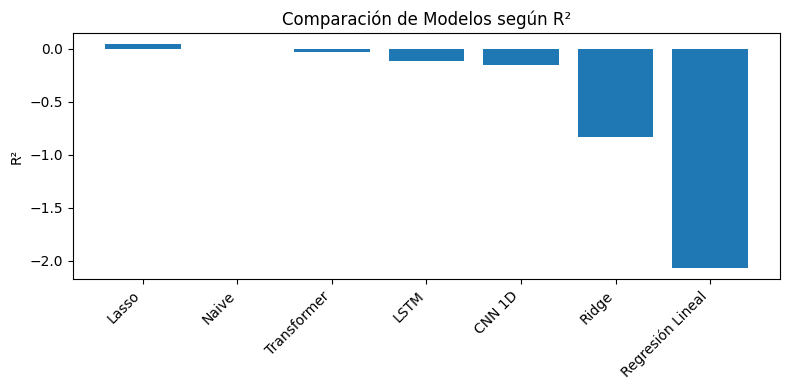

In [ ]:
plot_metric(
    metric="R2",
    ylabel="R²",
    title="Comparación de Modelos según R²"
)

### 7.2.4 Precisión direccional

La DA revela un resultado clave: Lasso, Transformer, Ridge y Regresión Lineal alcanzan 80%, lo que indica buena capacidad para predecir la dirección del cambio económico. No obstante, al combinar esta métrica con MAE y RMSE, se observa que solo Lasso mantiene simultáneamente alta precisión direccional y bajo error, lo que refuerza su elección como modelo final.

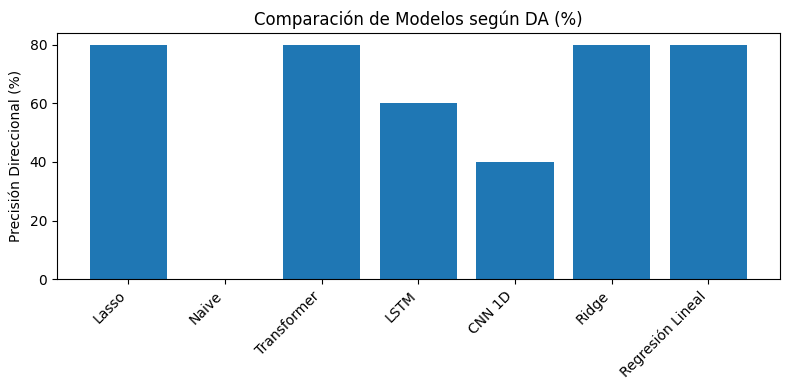

In [ ]:
plot_metric(
    metric="DA_%",
    ylabel="Precisión Direccional (%)",
    title="Comparación de Modelos según DA (%)"
)

# 8.0 Explicabilidad

Se utiliza SHAP (Shapley values) en este estudio porque, al trabajar con un modelo predictivo como Lasso aplicado a variables macroeconómicas, es necesario no solo evaluar la precisión del modelo, sino también comprender cómo y por qué cada variable influye en la predicción de la tasa de variación anual del PIB per cápita. SHAP permite descomponer cada predicción en contribuciones individuales de las variables explicativas, asignando un efecto positivo o negativo con base en un principio teórico sólido de la teoría de juegos, lo que garantiza interpretaciones consistentes y no arbitrarias. En el contexto del análisis macroeconómico, esta herramienta resulta clave para identificar los factores económicos que impulsan o limitan el crecimiento, fortalecer la validez económica de los resultados y asegurar que las conclusiones del modelo sean transparentes, interpretables y útiles para el análisis de políticas públicas.

## 8.1 SHAPLEY

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Extract the imputer and scaler steps from the fitted lasso pipeline
imputer = lasso.named_steps['imputer']
scaler = lasso.named_steps['scaler']

print("Imputer and Scaler extracted from Lasso pipeline.")

Imputer and Scaler extracted from Lasso pipeline.


**Reasoning**:
Now that the imputer and scaler have been extracted, I will apply these preprocessing steps to both the training and test feature sets to prepare them for SHAP analysis. It's crucial to maintain the original column names when converting back to DataFrames for better interpretability.



In [ ]:
import pandas as pd

# 2. Apply the extracted imputer to X_train
X_train_imputed = imputer.transform(X_train)

# 3. Apply the extracted imputer to X_test
X_test_imputed = imputer.transform(X_test)

# 4. Apply the extracted scaler to the X_train_imputed
X_train_preprocessed = scaler.transform(X_train_imputed)

# 5. Apply the extracted scaler to the X_test_imputed
X_test_preprocessed = scaler.transform(X_test_imputed)

# 6. Convert X_train_preprocessed into a pandas DataFrame
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=X_train.columns)

# 7. Convert X_test_preprocessed into a pandas DataFrame
X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed, columns=X_test.columns)

print("Training and test feature sets preprocessed and converted to DataFrames.")

Training and test feature sets preprocessed and converted to DataFrames.


In [ ]:
import shap

# 1. Initialize SHAP LinearExplainer
# The background dataset for the explainer should be the preprocessed training data
# The model to explain is the 'model' step within the lasso pipeline
explainer = shap.LinearExplainer(lasso.named_steps['model'], X_train_preprocessed_df)

print("SHAP LinearExplainer initialized.")

SHAP LinearExplainer initialized.


In [ ]:
print("Calculating SHAP values...")

# Calculate SHAP values for the training set
shap_values_train = explainer.shap_values(X_train_preprocessed_df)

# Calculate SHAP values for the test set
shap_values_test = explainer.shap_values(X_test_preprocessed_df)

print("SHAP values calculated for training and test sets.")

Calculating SHAP values...
SHAP values calculated for training and test sets.


### 8.1.1 SHAP global

/tmp/ipython-input-1336613214.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_train, X_train_preprocessed_df, plot_type="bar", show=False)


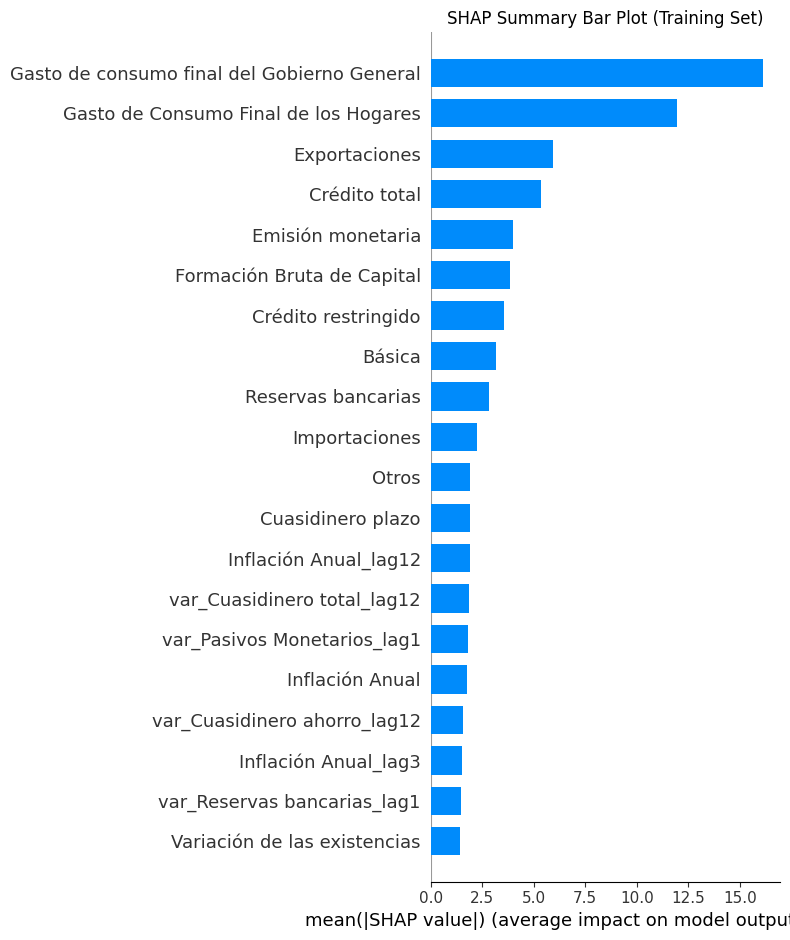

SHAP summary bar plot for the training set displayed.


In [ ]:
import matplotlib.pyplot as plt

# 1. Create a SHAP summary bar plot for the training set
shap.summary_plot(shap_values_train, X_train_preprocessed_df, plot_type="bar", show=False)
plt.title("SHAP Summary Bar Plot (Training Set)")
plt.tight_layout()
plt.show()

print("SHAP summary bar plot for the training set displayed.")

El gráfico de importancia global SHAP evidencia que el crecimiento del PIB per cápita está explicado principalmente por variables de demanda agregada, destacándose el gasto de consumo final del Gobierno General y el gasto de consumo final de los hogares como los factores con mayor impacto promedio en las predicciones del modelo Lasso. Esto sugiere que, en el período analizado, el dinamismo económico depende en gran medida del impulso fiscal y del consumo privado, por encima de variables puramente monetarias. En un segundo nivel de relevancia aparecen las exportaciones, el crédito total, la emisión monetaria y la formación bruta de capital, lo que refleja la interacción entre sector externo, financiamiento e inversión como motores complementarios del crecimiento. Las variables inflacionarias y sus rezagos muestran un impacto menor pero persistente, indicando que la inflación influye más como un factor de ajuste intertemporal que como un determinante directo del crecimiento. En conjunto, los resultados SHAP confirman que el modelo captura una estructura económica coherente, donde la política fiscal y el consumo interno juegan un rol central en la evolución del PIB per cápita.

### 8.1.2 SHAP resumen

/tmp/ipython-input-2755256071.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_train, X_train_preprocessed_df, show=False)


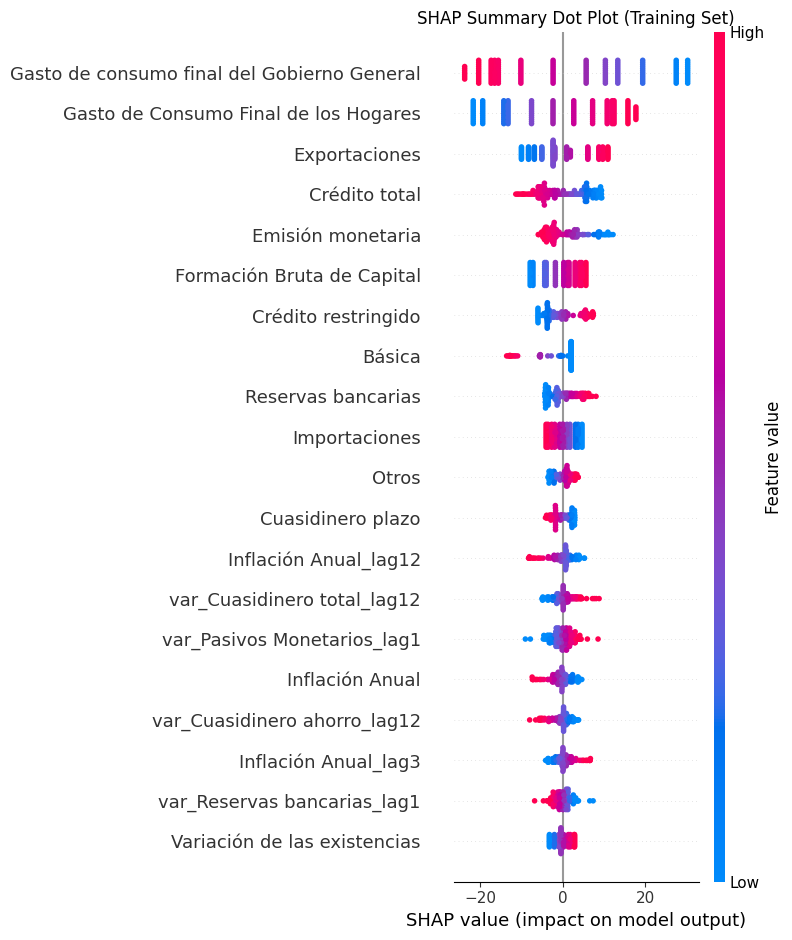

SHAP summary dot plot for the training set displayed.


In [ ]:
import matplotlib.pyplot as plt

# Create a SHAP summary dot plot for the training set
shap.summary_plot(shap_values_train, X_train_preprocessed_df, show=False)
plt.title("SHAP Summary Dot Plot (Training Set)")
plt.tight_layout()
plt.show()

print("SHAP summary dot plot for the training set displayed.")

El SHAP summary dot plot permite analizar no solo la importancia de las variables, sino también el sentido de su efecto sobre el crecimiento del PIB per cápita. Se observa que valores altos del gasto de consumo final del Gobierno General y del consumo final de los hogares (puntos rojos) se asocian predominantemente con impactos positivos en la predicción, confirmando que un mayor gasto público y privado impulsa el crecimiento económico. De manera similar, exportaciones, crédito total, emisión monetaria y formación bruta de capital muestran una relación mayoritariamente positiva, lo que evidencia el rol del sector externo, el financiamiento y la inversión como motores del crecimiento. En contraste, variables como importaciones y ciertos agregados monetarios presentan efectos mixtos, reflejando que incrementos en estas pueden tener impactos tanto positivos como negativos dependiendo del contexto económico. Finalmente, las variables inflacionarias y sus rezagos exhiben efectos más concentrados alrededor de cero y con signos alternantes, indicando que la inflación influye principalmente como un factor de ajuste y transmisión intertemporal, más que como un determinante directo del crecimiento del PIB per cápita. En conjunto, el gráfico confirma una estructura económica coherente dominada por la demanda agregada, complementada por factores financieros y externos.

/tmp/ipython-input-1511126858.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_test, X_test_preprocessed_df, show=False)


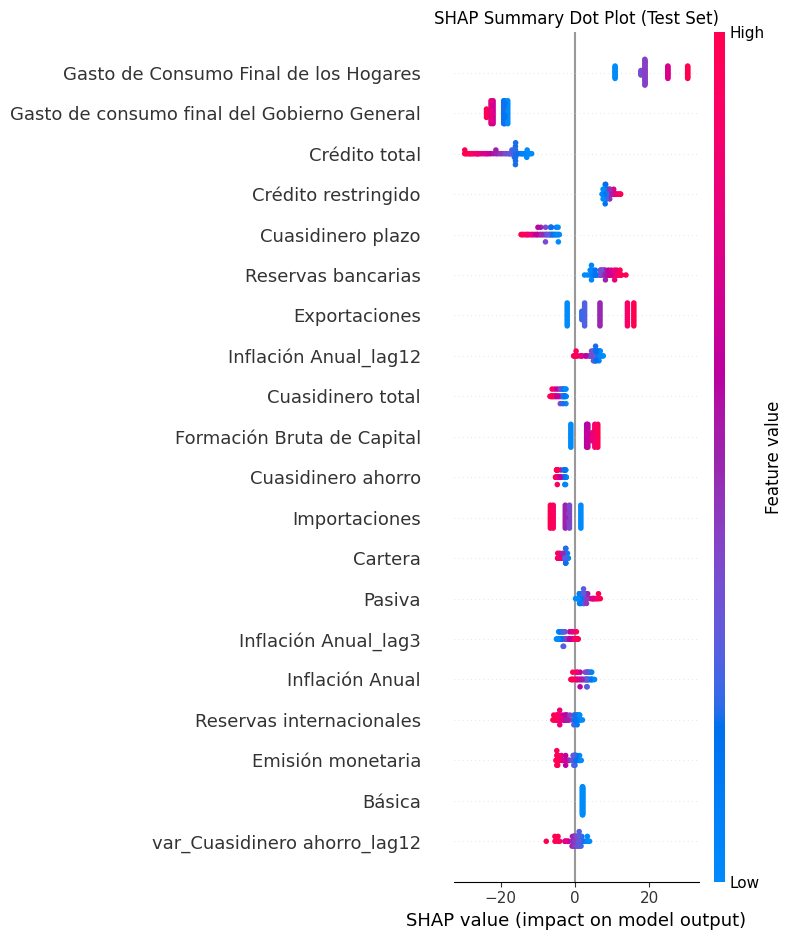

SHAP summary dot plot for the test set displayed.


In [ ]:
import matplotlib.pyplot as plt

# Create a SHAP summary dot plot for the test set
shap.summary_plot(shap_values_test, X_test_preprocessed_df, show=False)
plt.title("SHAP Summary Dot Plot (Test Set)")
plt.tight_layout()
plt.show()

print("SHAP summary dot plot for the test set displayed.")

El SHAP summary dot plot del conjunto de prueba (test set) confirma que la estructura explicativa del modelo se mantiene estable fuera de la muestra, lo que respalda su capacidad de generalización. Se observa que el gasto de consumo final de los hogares y el gasto de consumo final del Gobierno General continúan siendo los determinantes más influyentes del crecimiento del PIB per cápita, con valores altos asociados mayoritariamente a impactos positivos en la predicción, reforzando el papel central de la demanda agregada. Asimismo, variables financieras como el crédito total, el crédito restringido, el cuasidinero y las reservas bancarias muestran efectos relevantes y consistentes, lo que evidencia la importancia del sistema financiero en la dinámica del crecimiento económico. Las exportaciones y la formación bruta de capital mantienen un impacto positivo moderado, mientras que las importaciones y algunas variables monetarias presentan efectos mixtos, reflejando dependencias contextuales propias de economías abiertas. Finalmente, las variables inflacionarias y sus rezagos conservan impactos acotados alrededor de cero, lo que sugiere que su influencia es indirecta y de ajuste temporal. En conjunto, el gráfico del conjunto de prueba valida la coherencia económica del modelo y demuestra que las relaciones identificadas no responden a sobreajuste, sino a patrones estructurales robustos.

In [ ]:
import pandas as pd

hyperparameters = {
    "ARIMA": {
        "p": 0,
        "d": 1,
        "q": 2
    },
    "Regresión Lineal": {
        "Hiperparámetros": "Por defecto (no se ajustaron explícitamente)"
    },
    "Ridge": {
        "alpha": 1.0
    },
    "Lasso": {
        "alpha": 0.001,
        "max_iter": 10000
    },
    "Transformer": {
        "d_model": 32,
        "n_heads": 2,
        "ff_dim": 64,
        "dropout": 0.2,
        "learning_rate": 0.001,
        "clipnorm": 1.0,
        "patience_early_stopping": 10,
        "factor_reduce_lr": 0.5,
        "min_lr": 1e-6,
        "epochs": 400,
        "batch_size": 16
    },
    "LSTM": {
        "units": 16,
        "kernel_regularizer": "l2(0.01)",
        "dropout": 0.2,
        "learning_rate": 0.001,
        "clipnorm": 1.0,
        "patience_early_stopping": 10,
        "factor_reduce_lr": 0.5,
        "min_lr": 1e-6,
        "epochs": 300,
        "batch_size": 16
    },
    "CNN 1D": {
        "filters_conv1d": 16,
        "kernel_size_conv1d": 3,
        "dropout": 0.2,
        "learning_rate": 0.001,
        "clipnorm": 1.0,
        "patience_early_stopping": 10,
        "factor_reduce_lr": 0.5,
        "min_lr": 1e-6,
        "epochs": 300,
        "batch_size": 16
    }
}

# Convertir el diccionario a DataFrame para una mejor visualización
# Para manejar los diferentes conjuntos de hiperparámetros de cada modelo
# creamos una lista de Series y luego concatenamos

series_list = []
for model_name, params in hyperparameters.items():
    s = pd.Series(params, name=model_name)
    series_list.append(s)

df_hyperparameters = pd.concat(series_list, axis=1).fillna('-').T

# Ajustar el orden de las columnas para mayor claridad si es necesario
# Por ejemplo, poner los parámetros de entrenamiento al final

print("Hiperparámetros de los modelos:")
print(df_hyperparameters.to_markdown())
